Chapter 4 - Results

Sections 4.1-4.2

Plots: Growth rate vs chloramphenicol concentration (Model and Raman). Raman measurements and Model quantities vs Chloramphenicol concentration and/or Growth rate. Model breakdown of RNA into rRNA and mRNA, and of mRNA into free, ribosome bound and inhibited mRNA. Quantitative analysis.

Comparing behaviour between expiremental Raman data and the stochastic growth model. Choosing model (or model derived) quantities that track Raman RNA and protein intensity behaviour.

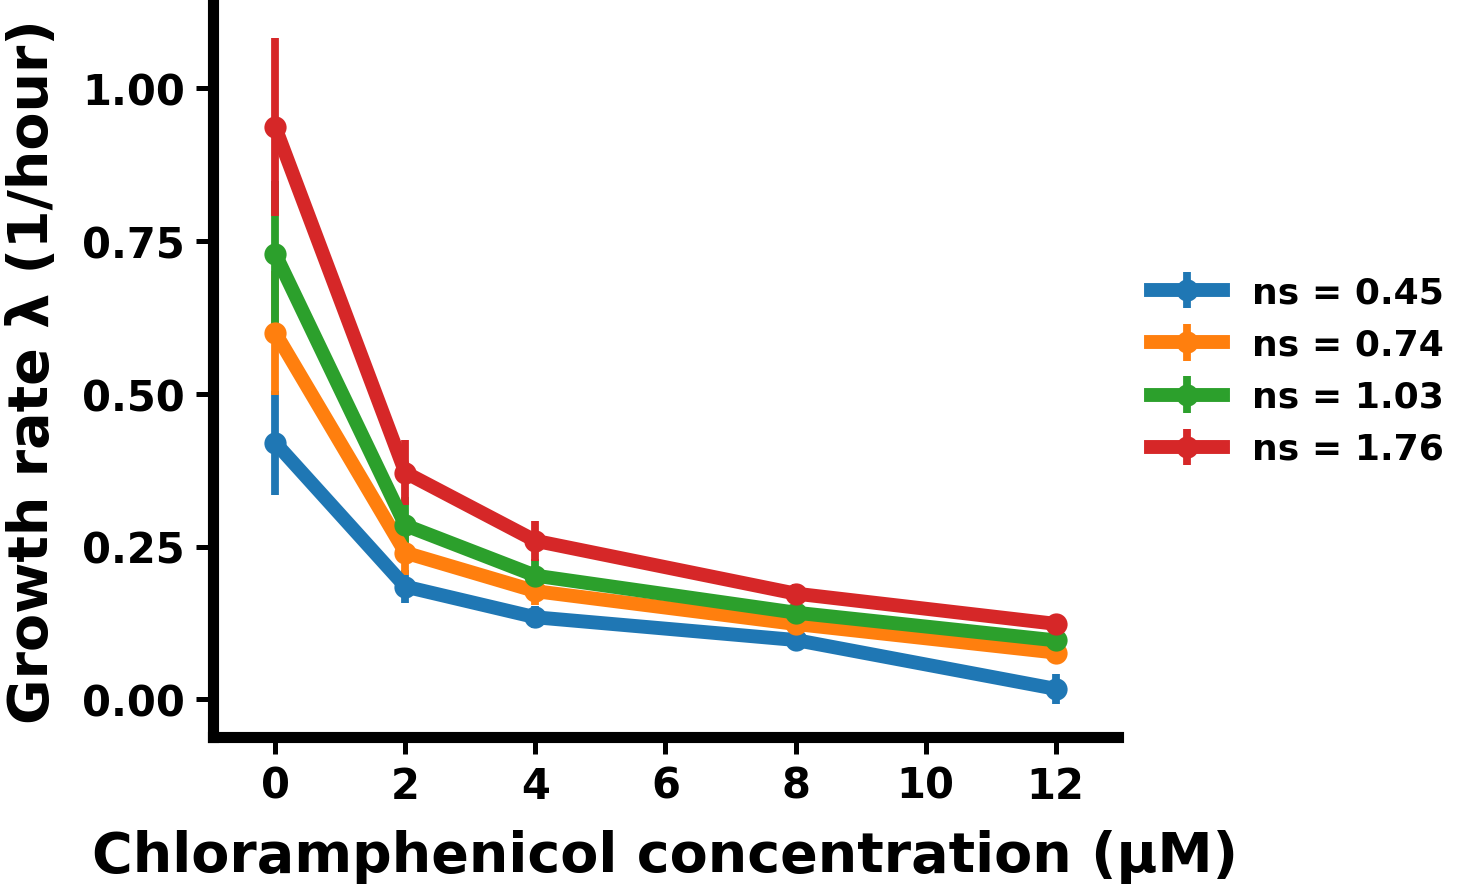

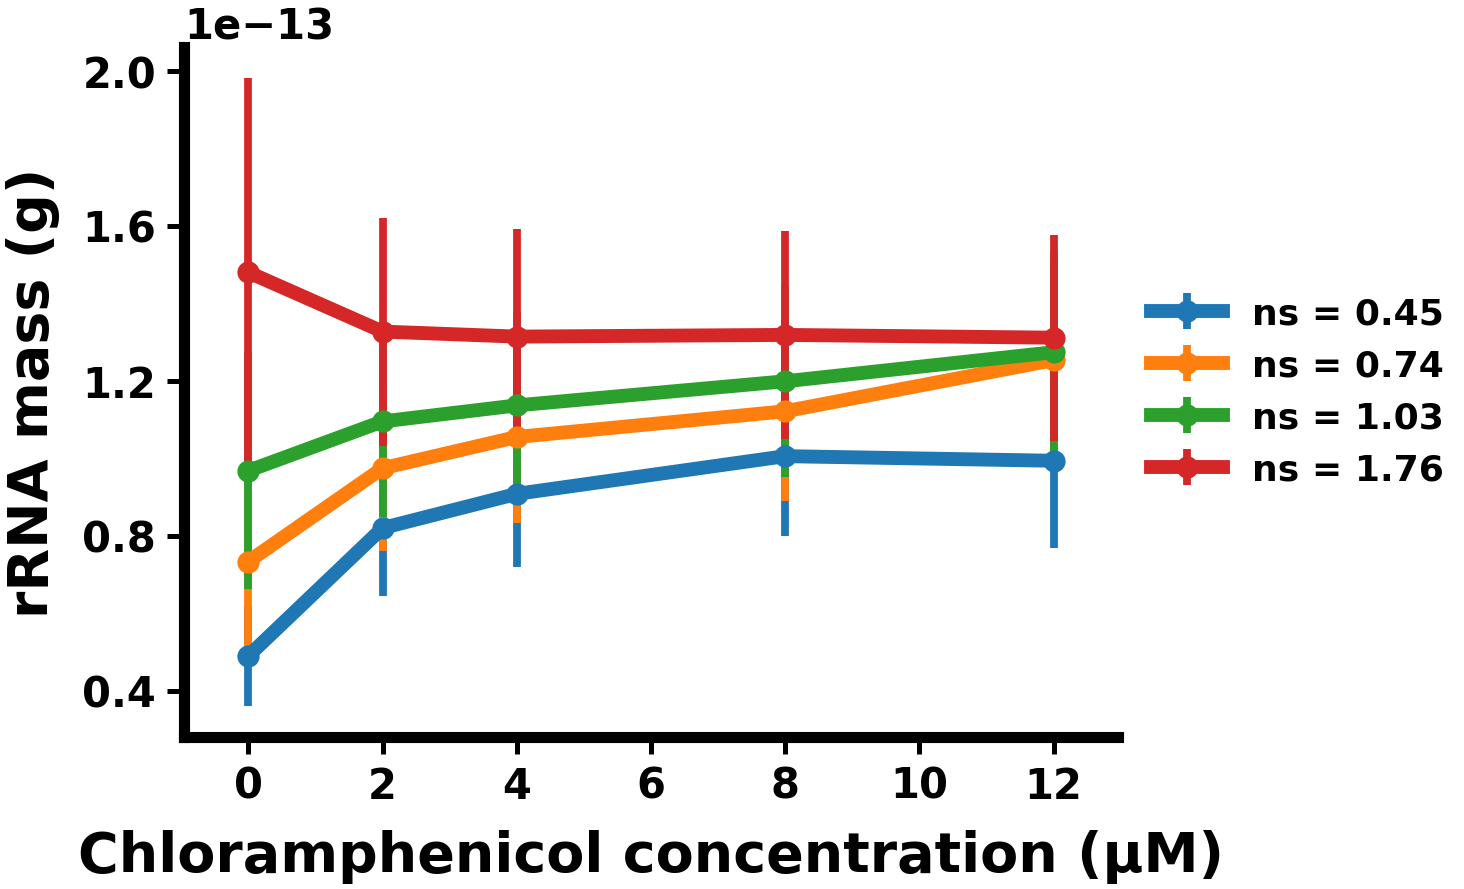

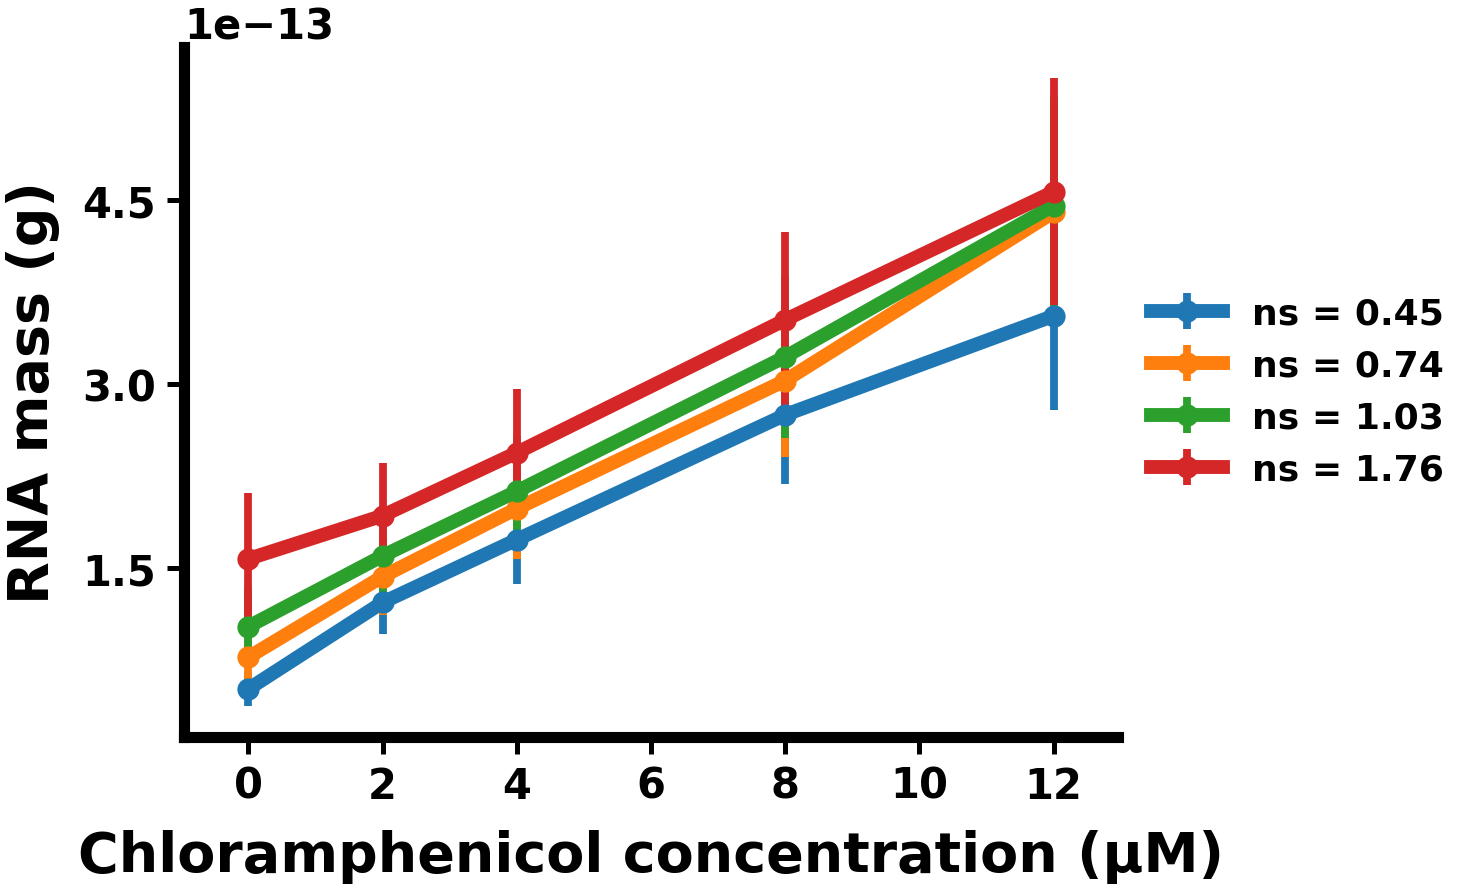

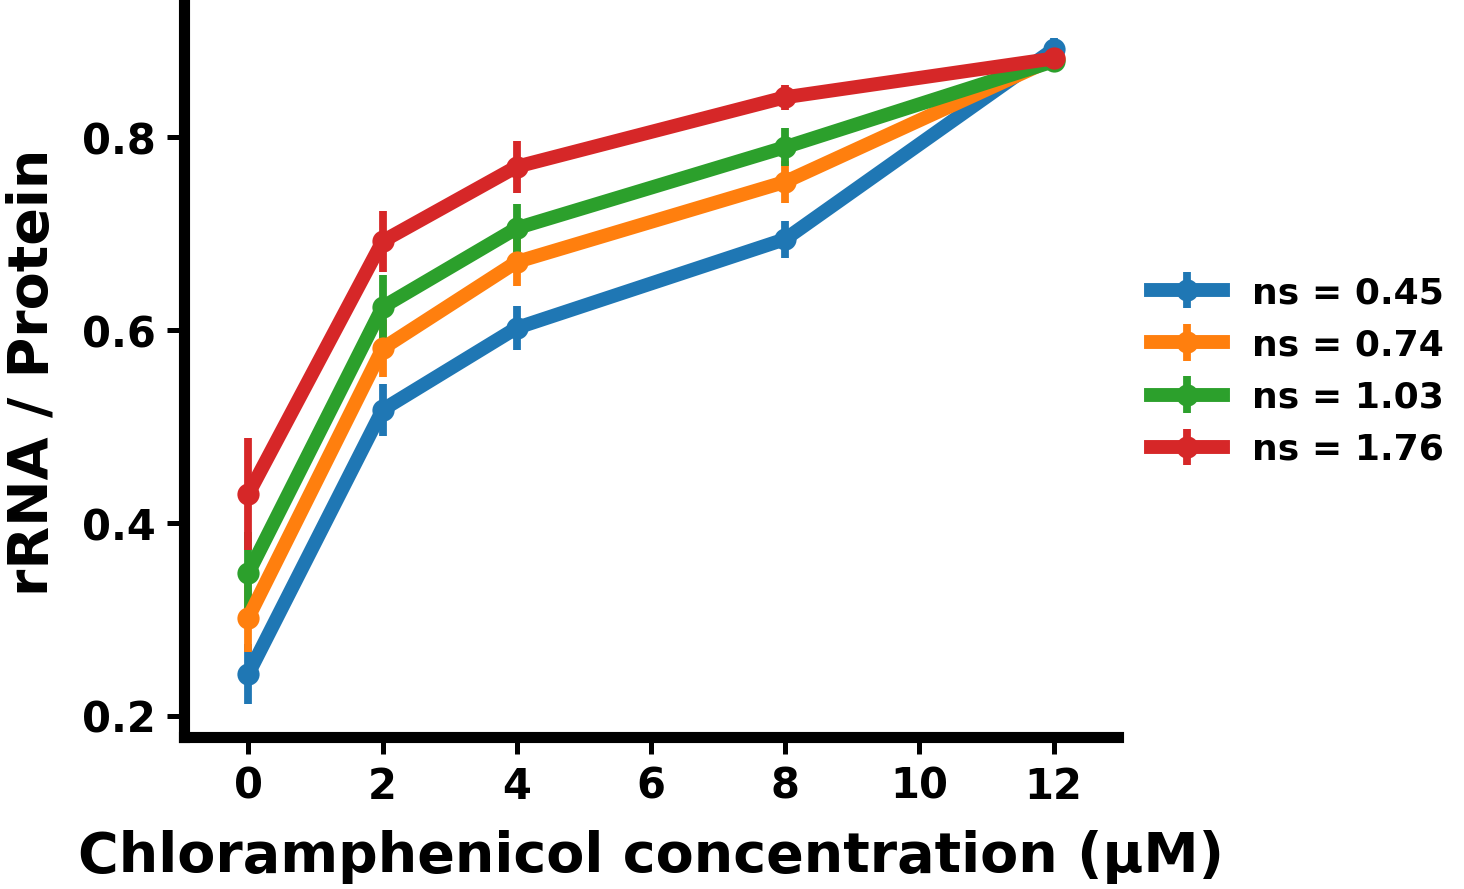

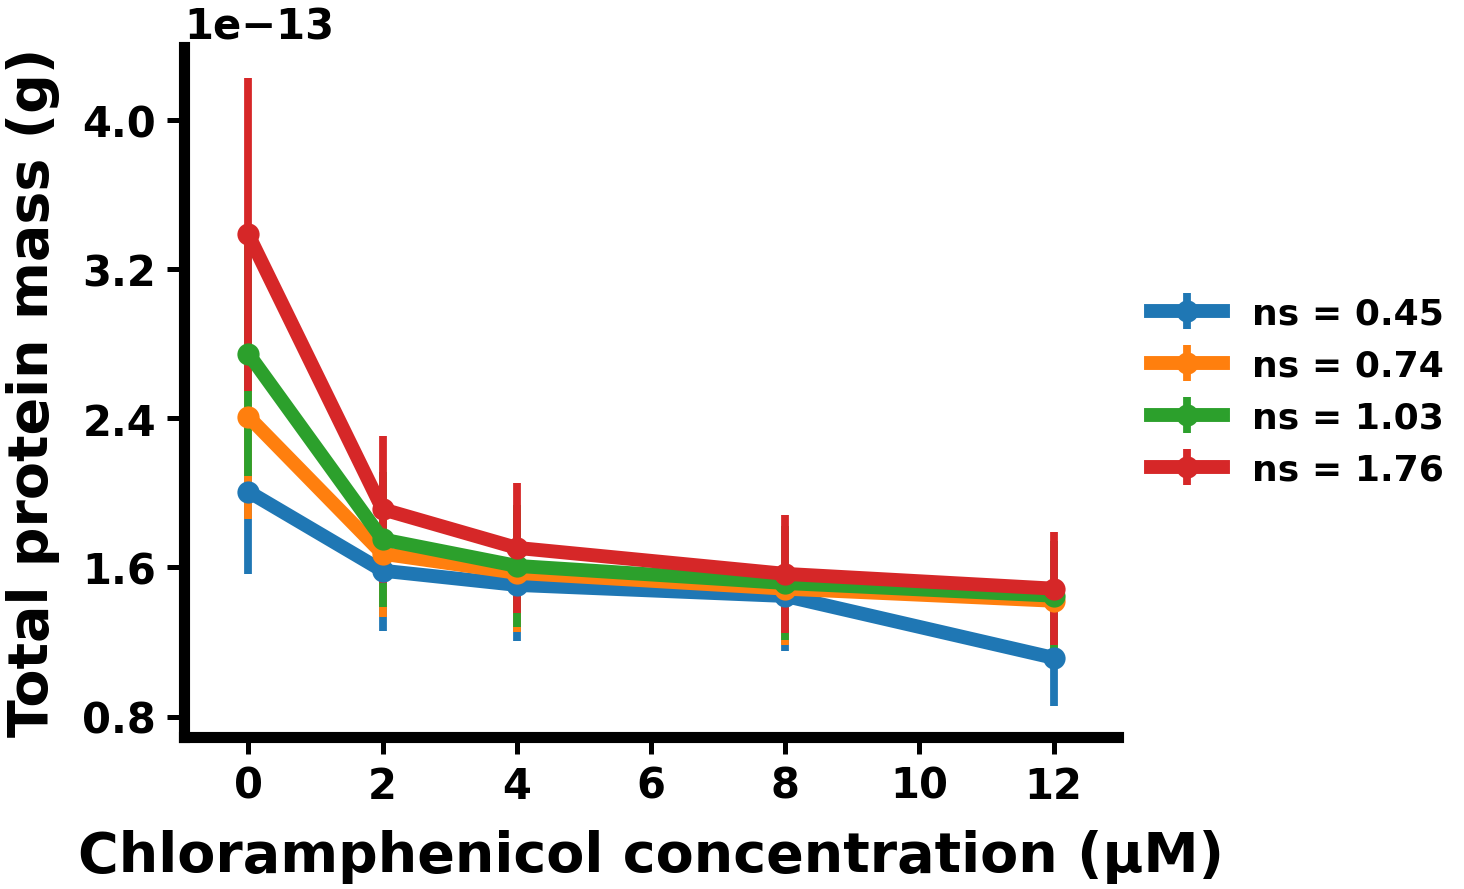

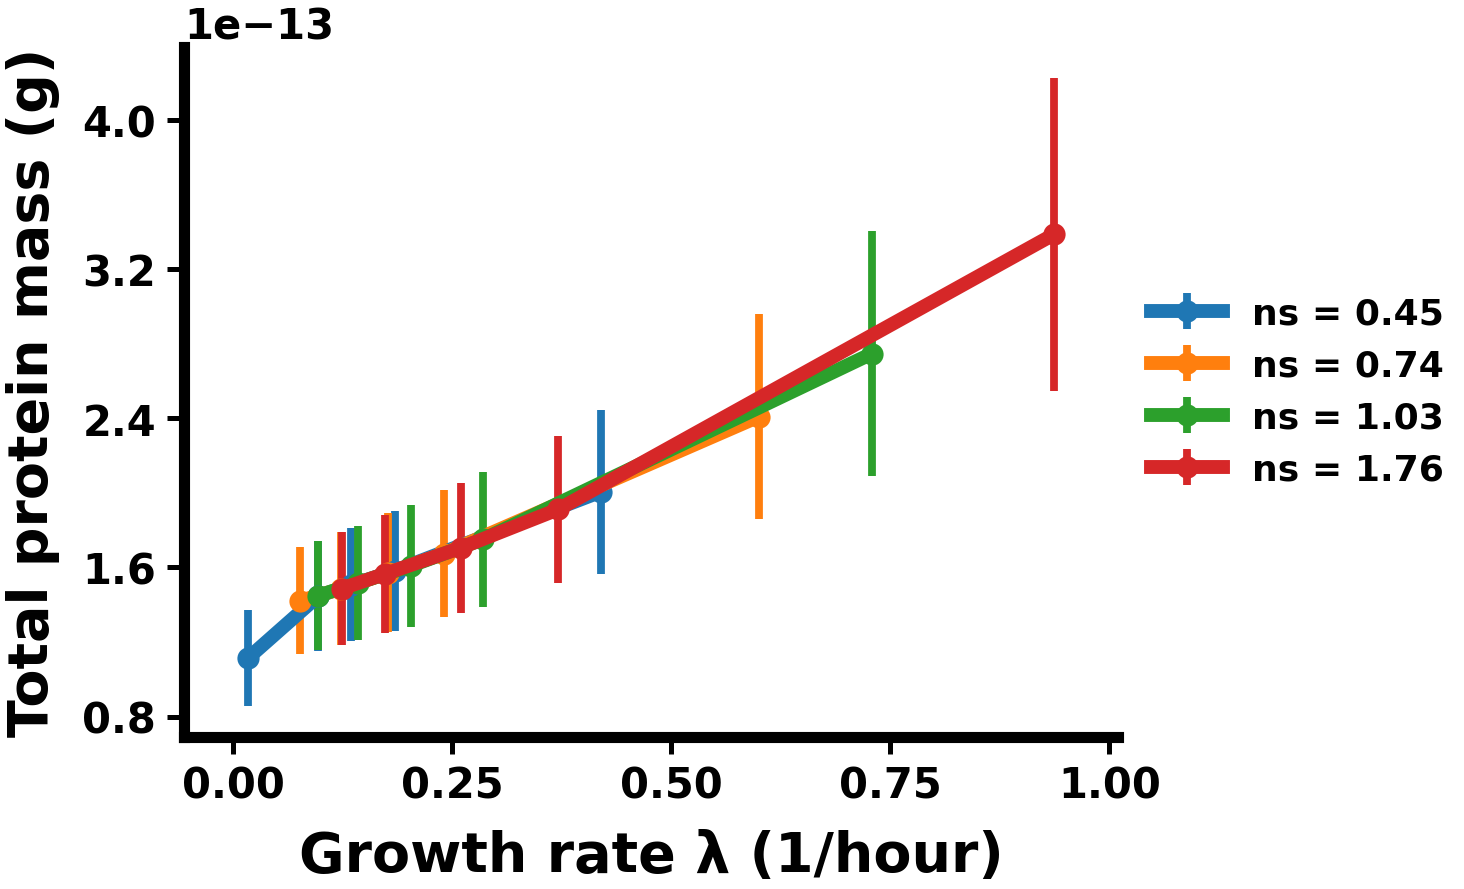

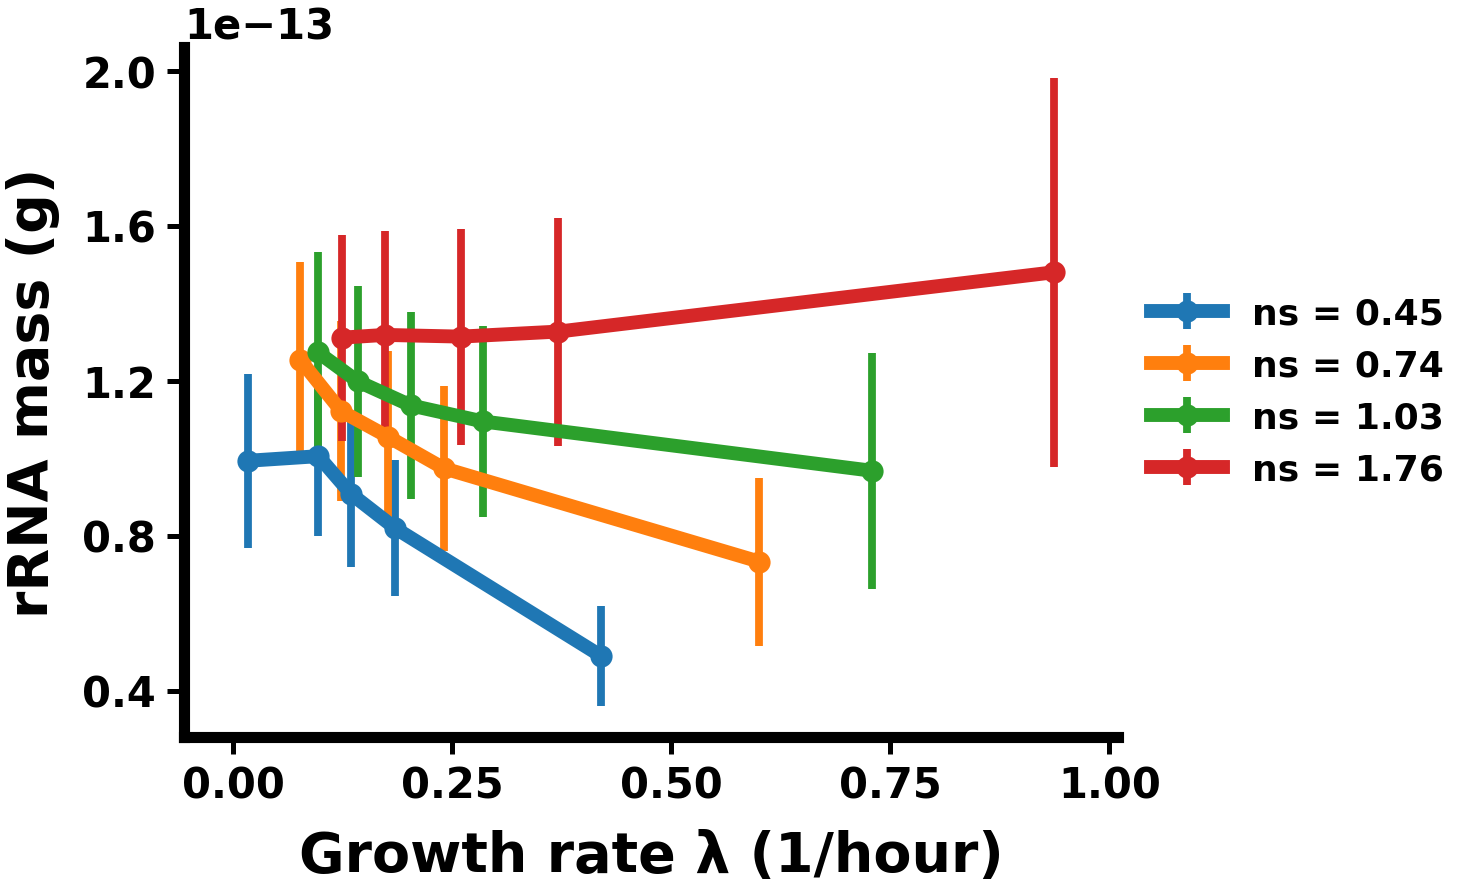

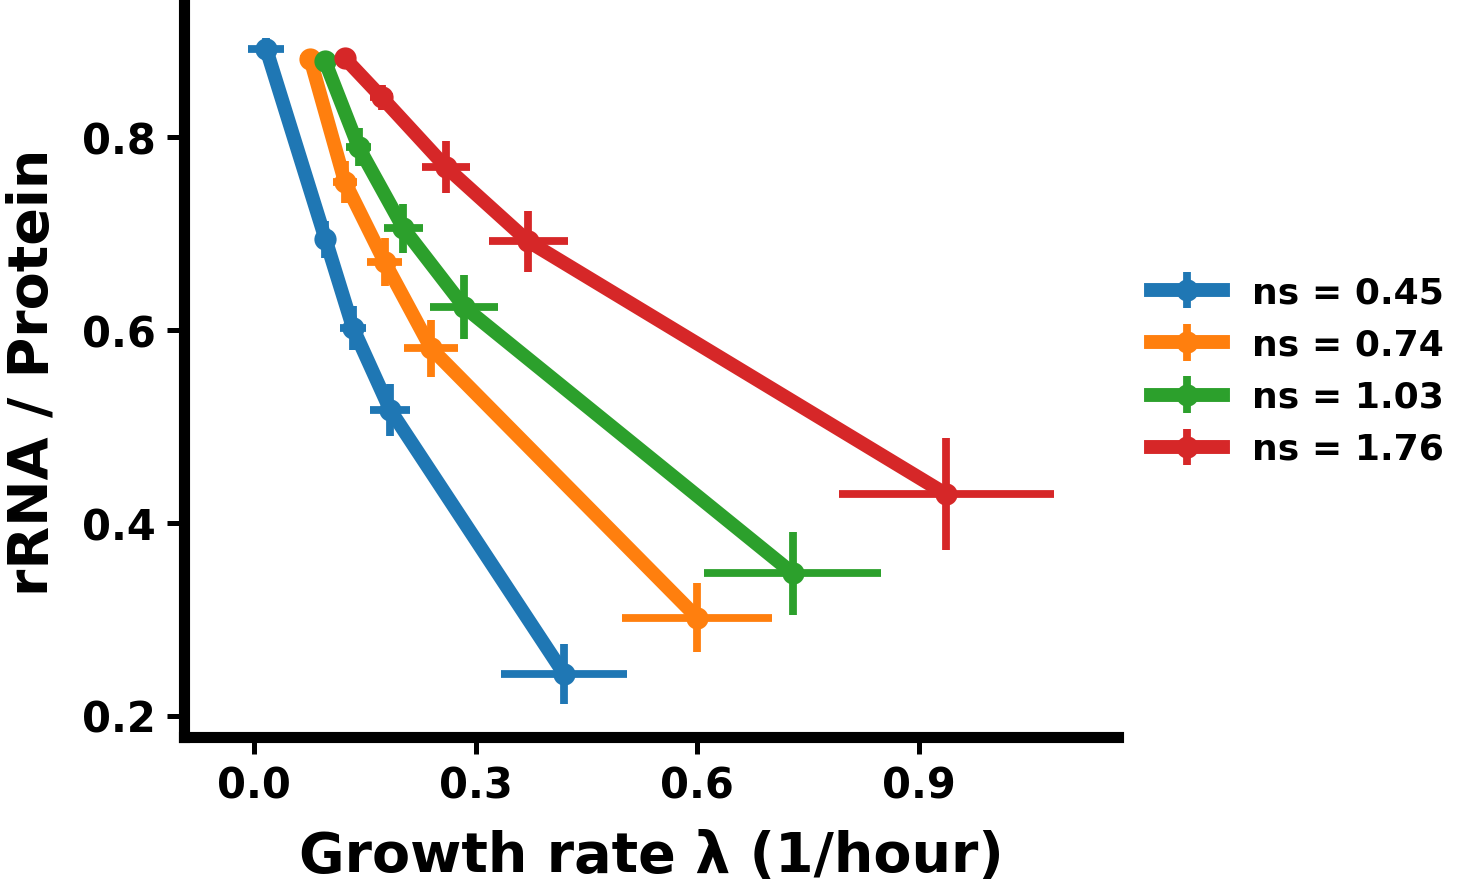

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
from matplotlib.ticker import MaxNLocator

plt.style.use("default")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (7.2, 4.5),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.linewidth": 4.0,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 13,
    "legend.frameon": False,
    "lines.linewidth": 5, #2.8
    "lines.markersize": 8,
    "errorbar.capsize": 4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03
})

NS_VALUES = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

SHOW_LEGEND = True

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo

    return ribo_mass, total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return (active * gamma / total_mass) * 60.0

def compute_rRNA_mass(df):
    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    total_nt = r_tot * RIBO_RNA_NT
    return (total_nt / AVOGADRO) * MW_NT

def compute_RNA_mass(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    total_nt = (mm + mt + mq + mr).to_numpy() + r_tot.to_numpy() * RIBO_RNA_NT
    return (total_nt / AVOGADRO) * MW_NT

def compute_protein_mass(df):
    _, total_mass = compute_mass_components(df)
    return (total_mass / AVOGADRO) * MW_AA

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:
        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, total_mass = compute_mass_components(df)
        growth = compute_growth(df, total_mass)
        rRNA = compute_rRNA_mass(df)
        RNA = compute_RNA_mass(df)
        protein = compute_protein_mass(df)
        ratio = rRNA / protein

        records.append({
            "ns": ns,
            "abx": abx,
            "mu_mean": np.mean(growth),
            "mu_sd": np.std(growth),
            "rRNA_mean": np.mean(rRNA),
            "rRNA_sd": np.std(rRNA),
            "RNA_mean": np.mean(RNA),
            "RNA_sd": np.std(RNA),
            "protein_mean": np.mean(protein),
            "protein_sd": np.std(protein),
            "ratio_mean": np.mean(ratio),
            "ratio_sd": np.std(ratio)
        })

df_model = pd.DataFrame(records)

def finish_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, labelpad=8, weight='bold')
    ax.set_ylabel(ylabel, labelpad=8, weight='bold')
    ax.tick_params(direction="out", length=6, width=1.8, pad=4)
    ax.margins(x=0.08, y=0.05)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    fig = ax.figure
    fig.tight_layout(pad=0.25)
    if SHOW_LEGEND:
        fig.subplots_adjust(right=0.78)

def plot_vs_abx(df, ycol, yerrcol, ylabel, filename):
    fig, ax = plt.subplots()
    for ns in NS_VALUES:
        subset = df[df["ns"] == ns].sort_values("abx")
        ax.errorbar(
            subset["abx"],
            subset[ycol],
            yerr=subset[yerrcol],
            fmt="-o",
            elinewidth=2.8,
            capthick=2.8,
            markeredgewidth=0,
            label=f"ns = {ns}"
        )
    finish_axes(ax, "Chloramphenicol concentration (µM)", ylabel)
    if SHOW_LEGEND:
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            handlelength=2.0
        )
    fig.savefig(filename)
    ax.set_xticks([0,2,4,6,8,10,12])
    plt.show()

def plot_vs_growth(df, ycol, yerrcol, ylabel, filename, xerrcol=None):
    fig, ax = plt.subplots()
    for ns in NS_VALUES:
        subset = df[df["ns"] == ns].sort_values("mu_mean")
        ax.errorbar(
            subset["mu_mean"],
            subset[ycol],
            yerr=subset[yerrcol],
            xerr=subset[xerrcol] if xerrcol is not None else None,
            fmt="-o",
            elinewidth=2.8,
            capthick=2.8,
            markeredgewidth=0,
            label=f"ns = {ns}"
        )
    finish_axes(ax, "Growth rate λ (1/hour)", ylabel)
    if SHOW_LEGEND:
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            handlelength=2.0
        )
    fig.savefig(filename)
    plt.show()

plot_vs_abx(df_model, "mu_mean", "mu_sd", "Growth rate λ (1/hour)", "growth_vs_abx.png")
plot_vs_abx(df_model, "rRNA_mean", "rRNA_sd", "rRNA mass (g)", "rRNA_vs_abx.png")
plot_vs_abx(df_model, "RNA_mean", "RNA_sd", "RNA mass (g)", "RNA_vs_abx.png")
plot_vs_abx(df_model, "ratio_mean", "ratio_sd", "rRNA / Protein", "ratio_vs_abx.png")
plot_vs_abx(df_model, "protein_mean", "protein_sd", "Total protein mass (g)", "protein_vs_abx.png")

plot_vs_growth(df_model, "protein_mean", "protein_sd", "Total protein mass (g)", "protein_vs_growth.png")
plot_vs_growth(df_model, "rRNA_mean", "rRNA_sd", "rRNA mass (g)", "rRNA_vs_growth.png")
plot_vs_growth(df_model, "ratio_mean", "ratio_sd", "rRNA / Protein", "ratio_vs_growth.png", xerrcol="mu_sd")

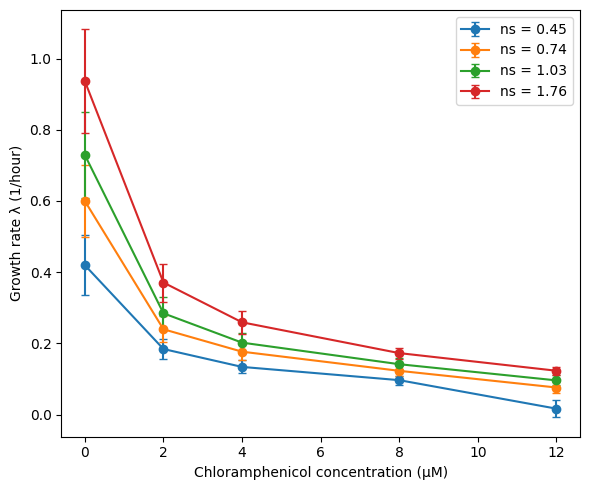

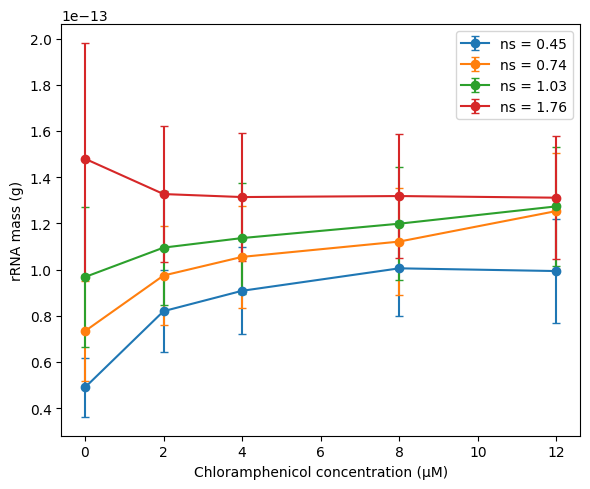

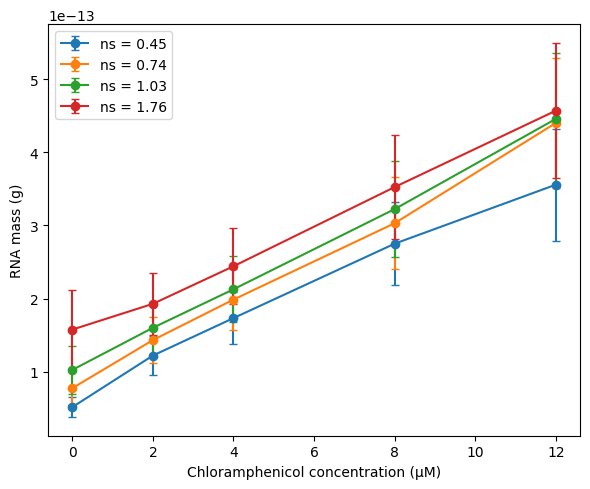

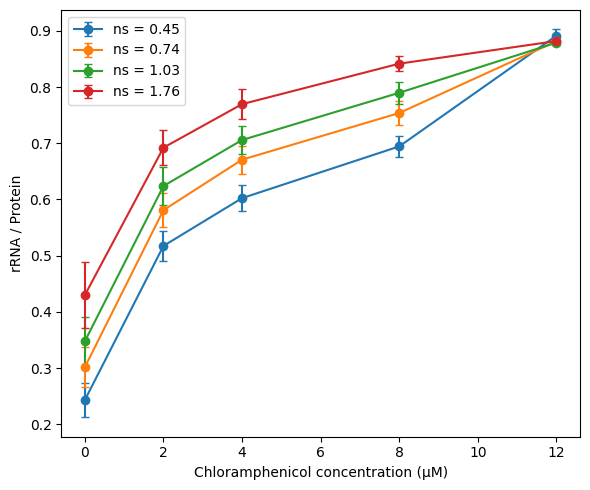

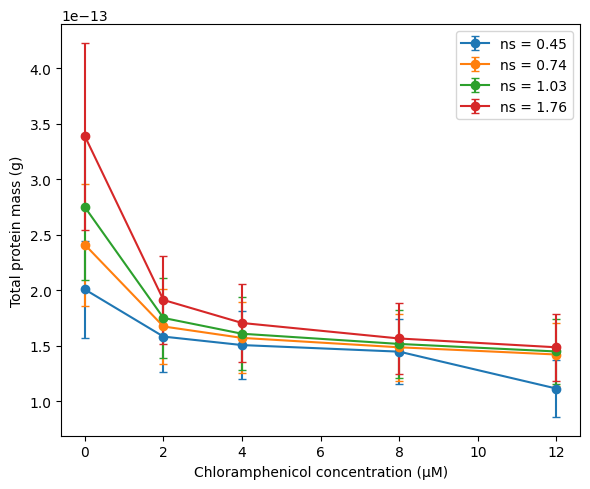

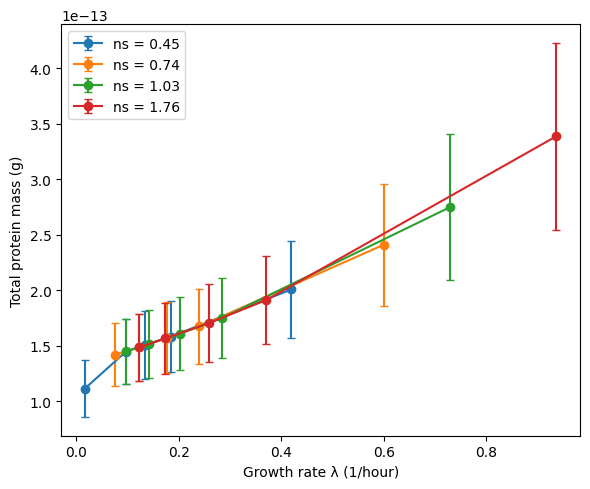

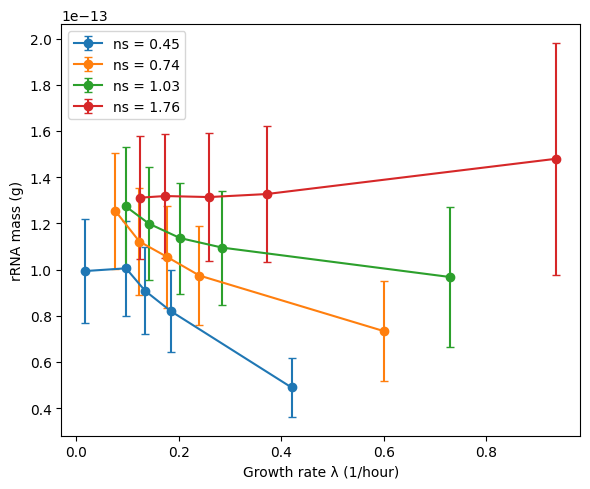

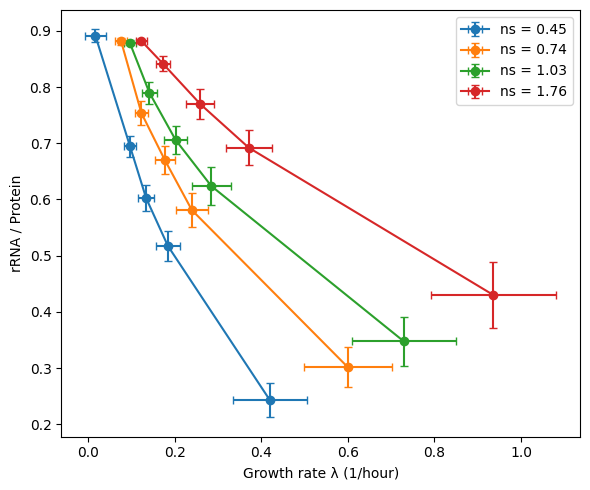

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

plt.style.use("default")

# PARAMETERS
NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]  # µM

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

AVOGADRO = 6.022e23
MW_AA = 110.0        # g/mol
MW_NT = 330.0        # g/mol

# HELPER FUNCTIONS
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr +
                      zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    total_mass = ribo_mass + non_ribo

    return ribo_mass, total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return (active * gamma / total_mass) * 60.0  # 1/hour

def compute_rRNA_mass(df):
    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    total_nt = r_tot * RIBO_RNA_NT
    return (total_nt / AVOGADRO) * MW_NT  # grams

def compute_RNA_mass(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    total_nt = (mm + mt + mq + mr).to_numpy() + r_tot.to_numpy() * RIBO_RNA_NT

    return (total_nt / AVOGADRO) * MW_NT

def compute_protein_mass(df):
    _, total_mass = compute_mass_components(df)
    return (total_mass / AVOGADRO) * MW_AA  # grams

# BUILD SUMMARY PER NS
records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, total_mass = compute_mass_components(df)

        growth = compute_growth(df, total_mass)
        rRNA   = compute_rRNA_mass(df)
        RNA   = compute_RNA_mass(df)
        protein = compute_protein_mass(df)

        ratio = rRNA / protein

        records.append({
            "ns": ns,
            "abx": abx,
            "mu_mean": np.mean(growth),
            "mu_sd": np.std(growth),
            "rRNA_mean": np.mean(rRNA),
            "rRNA_sd": np.std(rRNA),
            "RNA_mean": np.mean(RNA),
            "RNA_sd": np.std(RNA),
            "protein_mean": np.mean(protein),
            "protein_sd": np.std(protein),
            "ratio_mean": np.mean(ratio),
            "ratio_sd": np.std(ratio) #/ np.sqrt(len(ratio))
        })

df_model = pd.DataFrame(records)


# PLOT 1 — Growth vs Antibiotic

plt.figure(figsize=(6,5))

for ns in NS_VALUES:
    subset = df_model[df_model["ns"] == ns]
    plt.errorbar(
        subset["abx"],
        subset["mu_mean"],
        yerr=subset["mu_sd"],
        marker='o',
        capsize=3,
        label=f"ns = {ns}"
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("Growth rate λ (1/hour)")
# plt.title("Model: Growth vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 2 — rRNA vs Antibiotic
plt.figure(figsize=(6,5))

for ns in NS_VALUES:
    subset = df_model[df_model["ns"] == ns]
    plt.errorbar(
        subset["abx"],
        subset["rRNA_mean"],
        yerr=subset["rRNA_sd"],
        marker='o',
        capsize=3,
        label=f"ns = {ns}"
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("rRNA mass (g)")
# plt.title("Model: rRNA vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 2.5 — RNA vs Antibiotic
plt.figure(figsize=(6,5))

for ns in NS_VALUES:
    subset = df_model[df_model["ns"] == ns]
    plt.errorbar(
        subset["abx"],
        subset["RNA_mean"],
        yerr=subset["RNA_sd"],
        marker='o',
        capsize=3,
        label=f"ns = {ns}"
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("RNA mass (g)")
# plt.title("Model: RNA vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 3 — rRNA/Protein vs Antibiotic
plt.figure(figsize=(6,5))

for ns in NS_VALUES:
    subset = df_model[df_model["ns"] == ns]
    plt.errorbar(
        subset["abx"],
        subset["ratio_mean"],
        yerr=subset["ratio_sd"],
        marker='o',
        capsize=3,
        label=f"ns = {ns}"
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("rRNA / Protein")
# plt.title("Model: rRNA/Protein vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 4 — Protein vs Antibiotic
plt.figure(figsize=(6,5))

for ns in NS_VALUES:
    subset = df_model[df_model["ns"] == ns]
    plt.errorbar(
        subset["abx"],
        subset["protein_mean"],
        yerr=subset["protein_sd"],
        marker='o',
        capsize=3,
        label=f"ns = {ns}"
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("Total protein mass (g)")
# plt.title("Model: Protein vs Growth")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 4.5 — Protein vs Growth
plt.figure(figsize=(6,5))

for ns in NS_VALUES:
    subset = df_model[df_model["ns"] == ns]
    plt.errorbar(
        subset["mu_mean"],
        subset["protein_mean"],
        yerr=subset["protein_sd"],
        marker='o',
        capsize=3,
        label=f"ns = {ns}"
    )

plt.xlabel("Growth rate λ (1/hour)")
plt.ylabel("Total protein mass (g)")
# plt.title("Model: Protein vs Growth")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 5 — rRNA vs Growth
plt.figure(figsize=(6,5))

for ns in NS_VALUES:
    subset = df_model[df_model["ns"] == ns]
    plt.errorbar(
        subset["mu_mean"],
        subset["rRNA_mean"],
        yerr=subset["rRNA_sd"],
        marker='o',
        capsize=3,
        label=f"ns = {ns}"
    )

plt.xlabel("Growth rate λ (1/hour)")
plt.ylabel("rRNA mass (g)")
# plt.title("Model: rRNA vs Growth")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 3 — rRNA/Protein vs Growth
plt.figure(figsize=(6,5))

for ns in NS_VALUES:
    subset = df_model[df_model["ns"] == ns]
    plt.errorbar(
        subset["mu_mean"],
        subset["ratio_mean"],
        yerr=subset["ratio_sd"],
        xerr=subset["mu_sd"],
        marker='o',
        capsize=3,
        label=f"ns = {ns}"
    )

plt.xlabel("Growth rate λ (1/hour)")
plt.ylabel("rRNA / Protein")
# plt.title("Model: rRNA/Protein vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

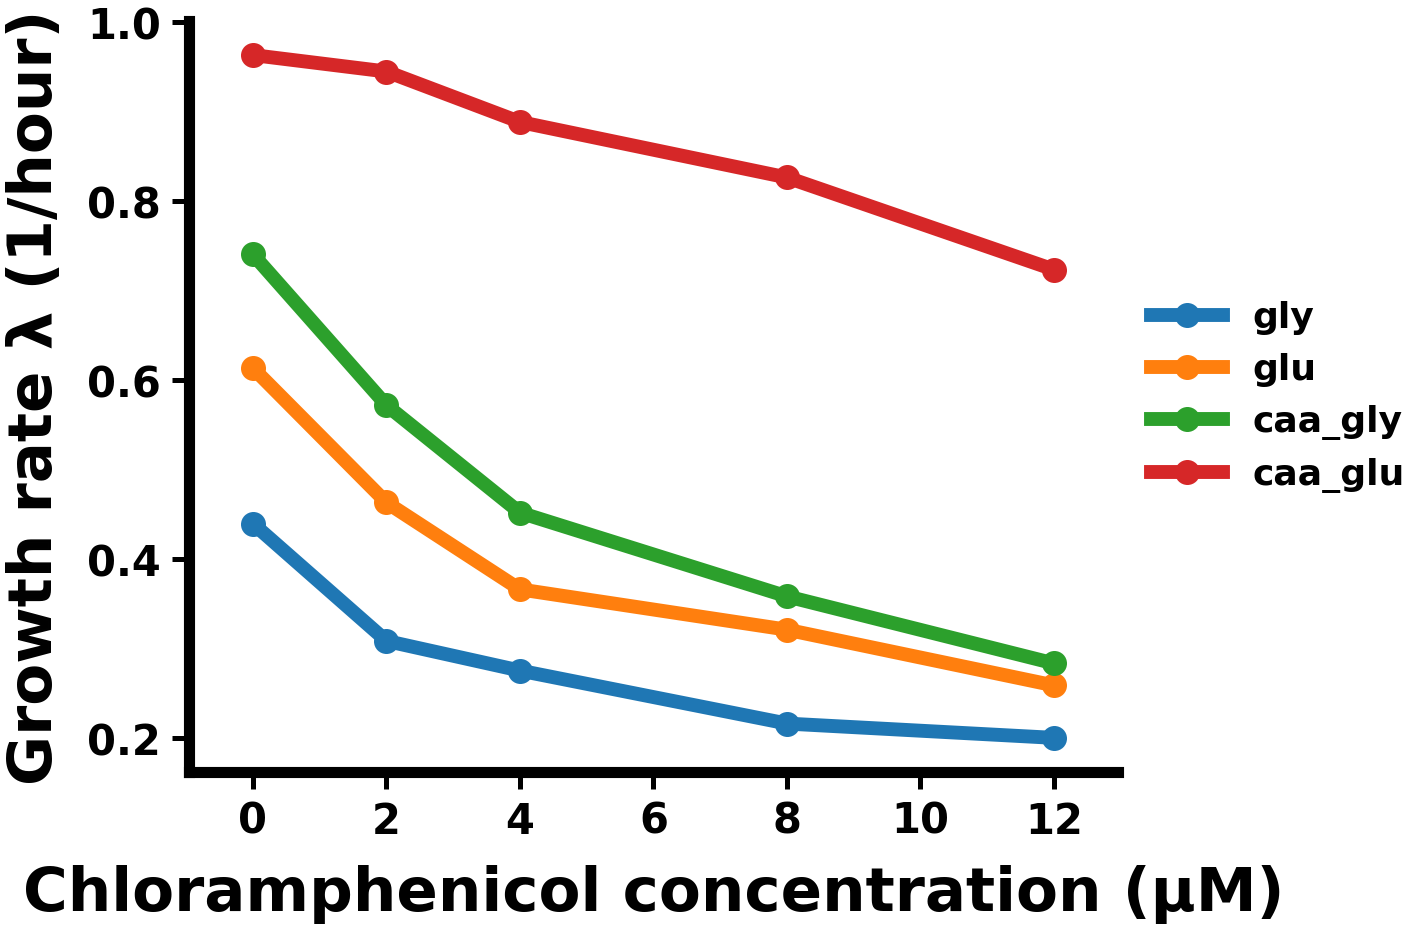

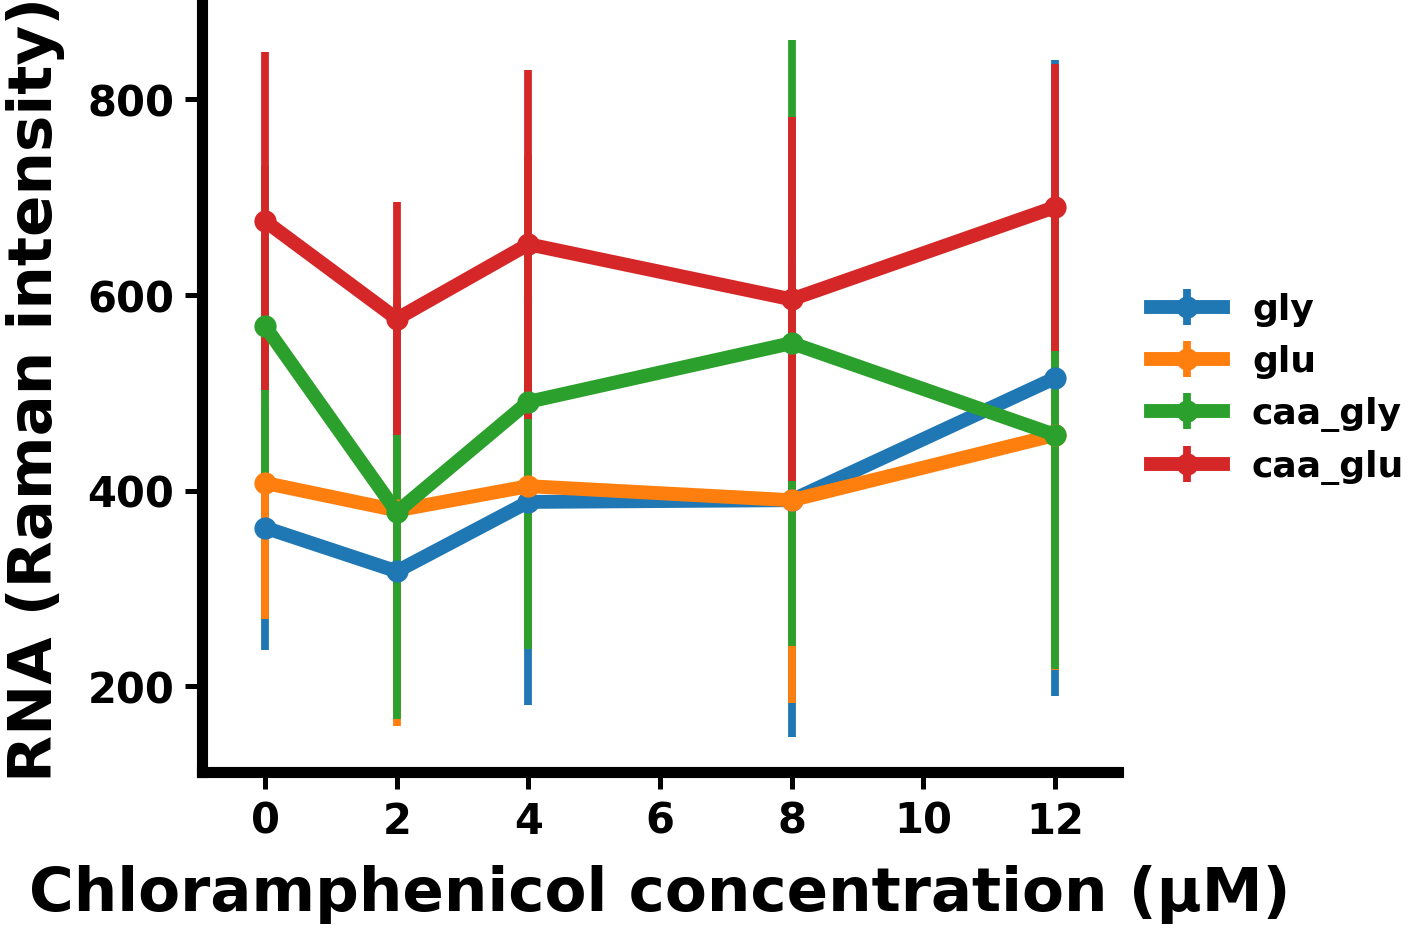

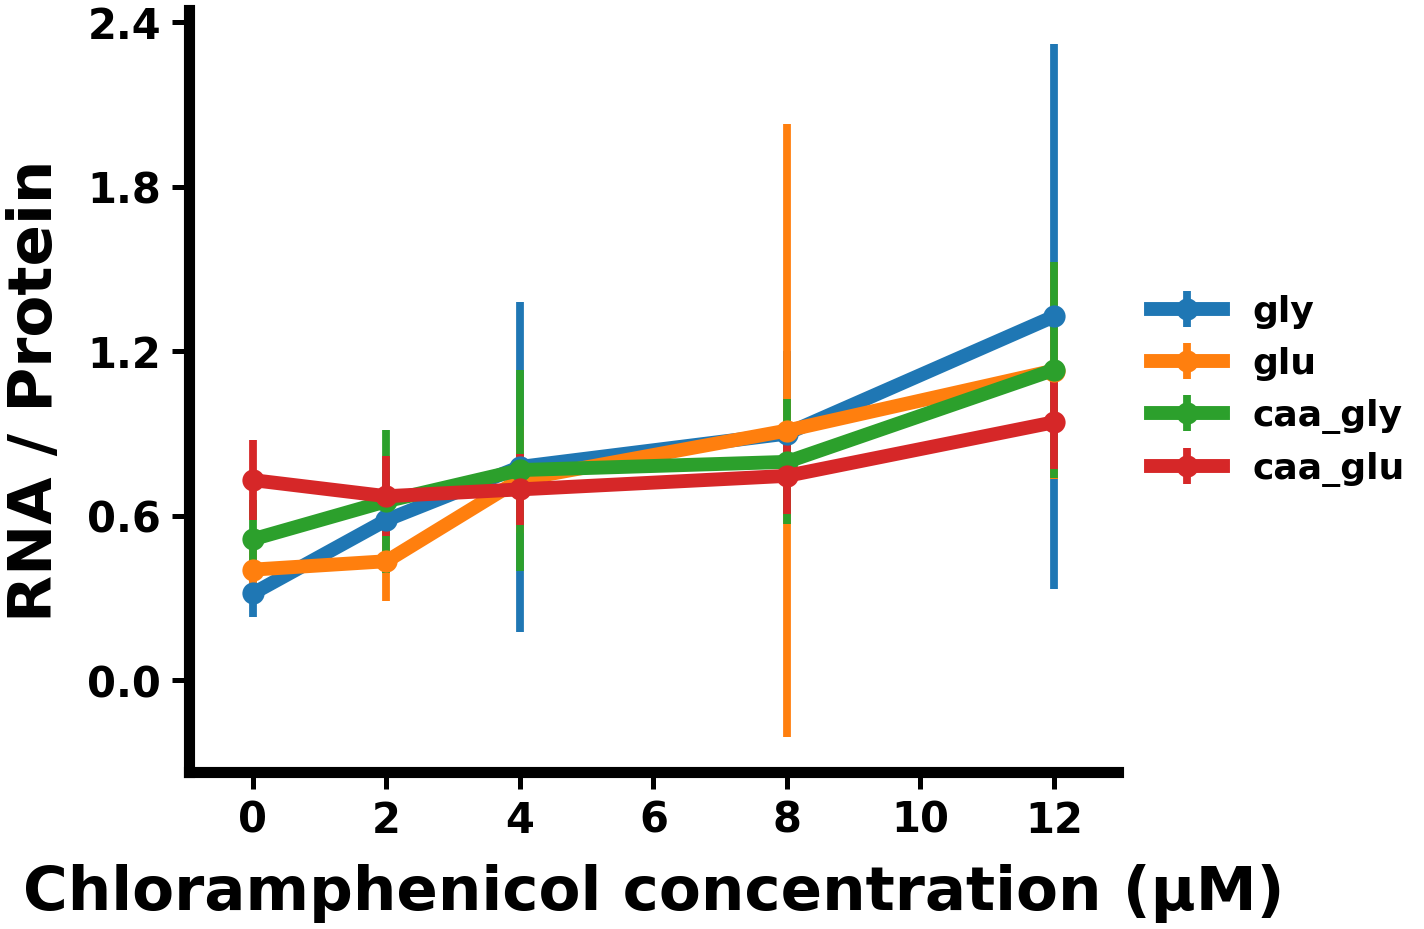

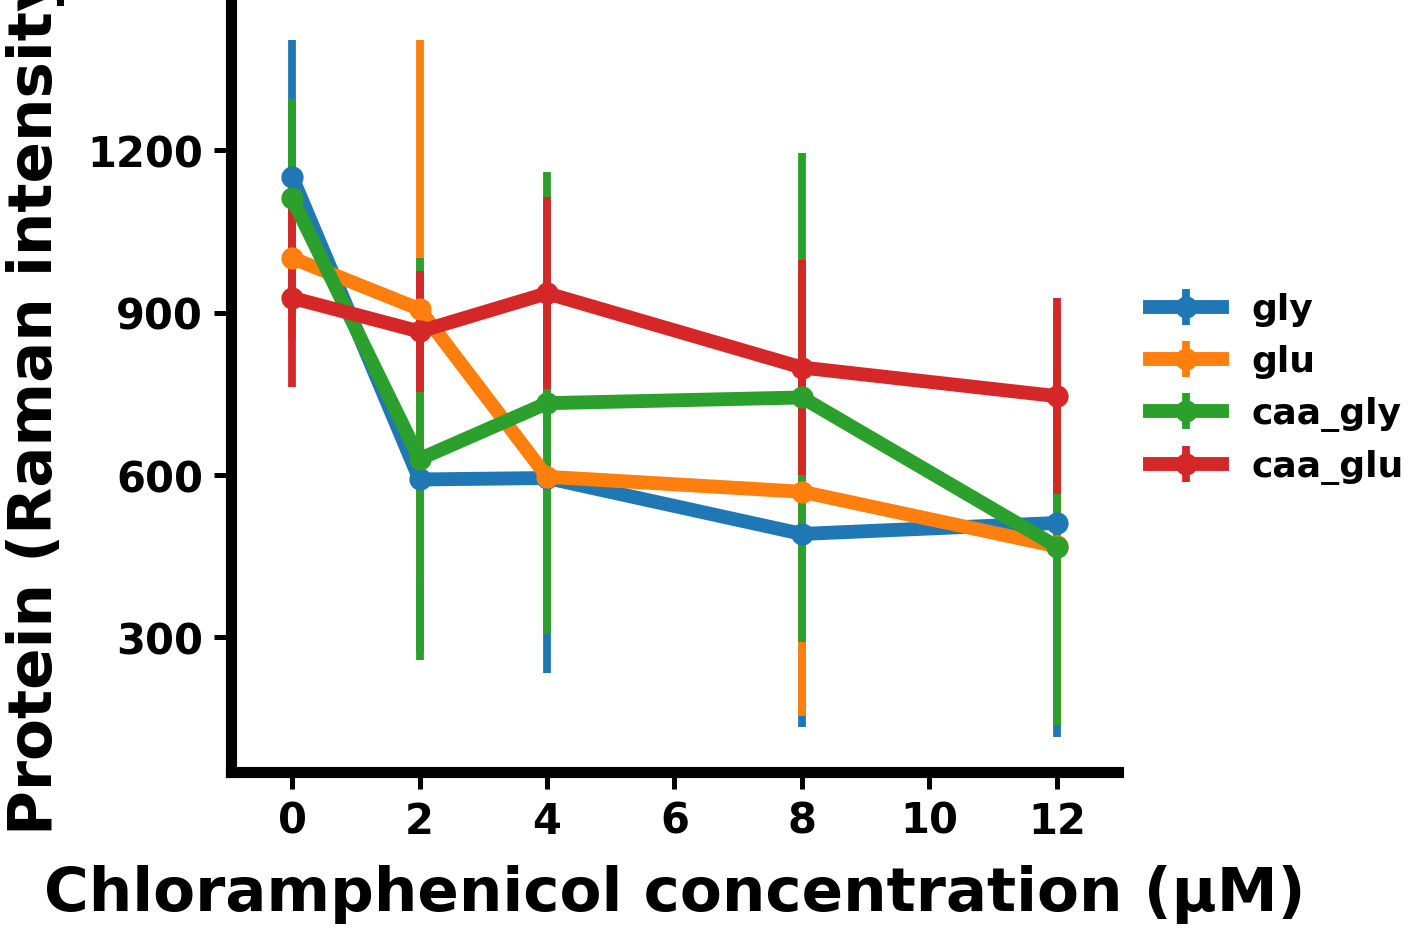

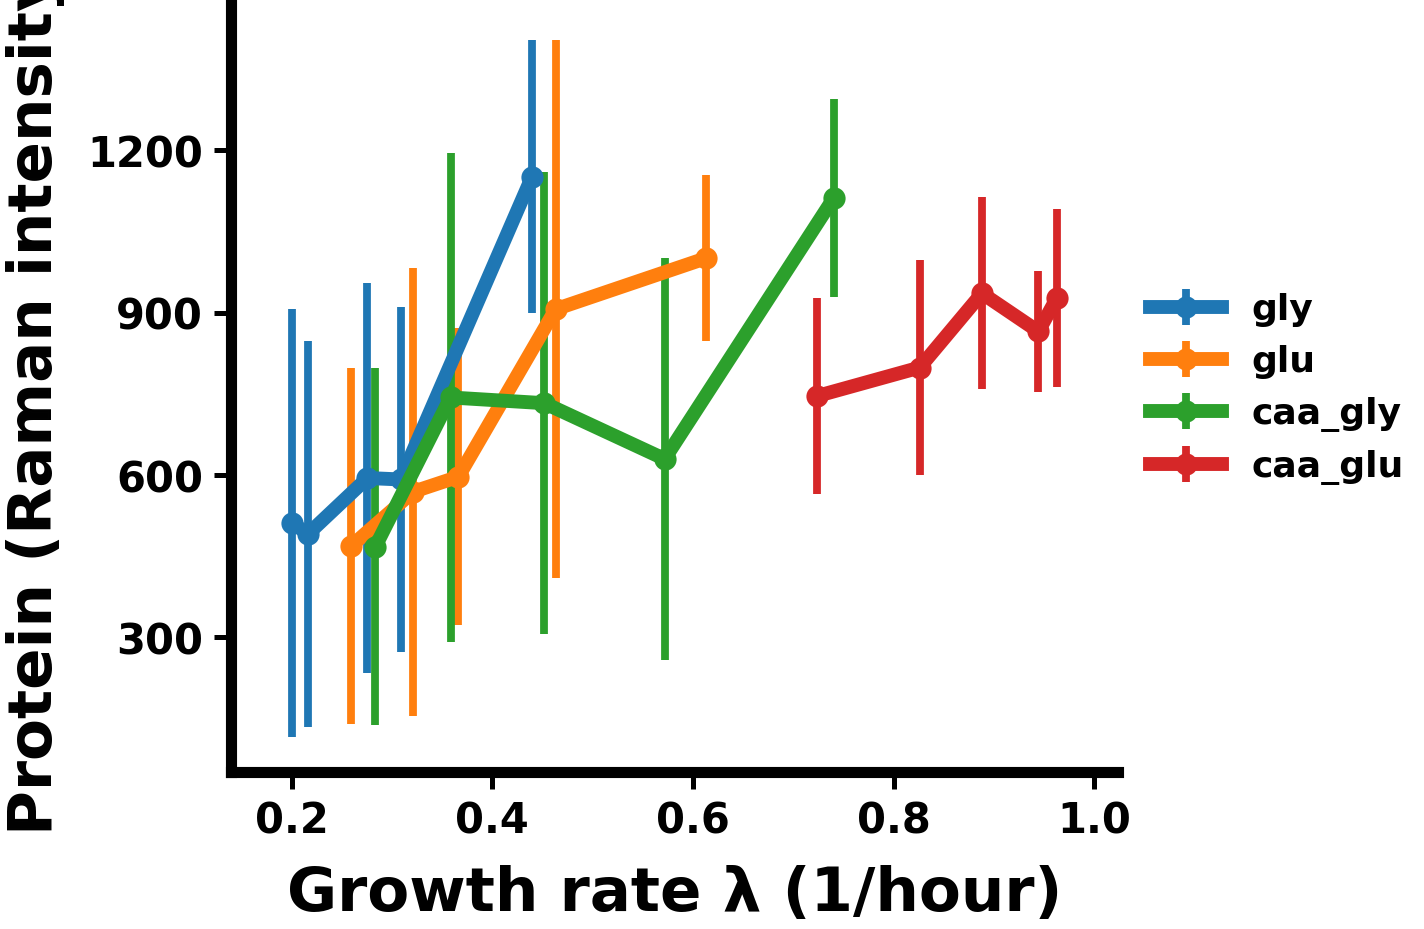

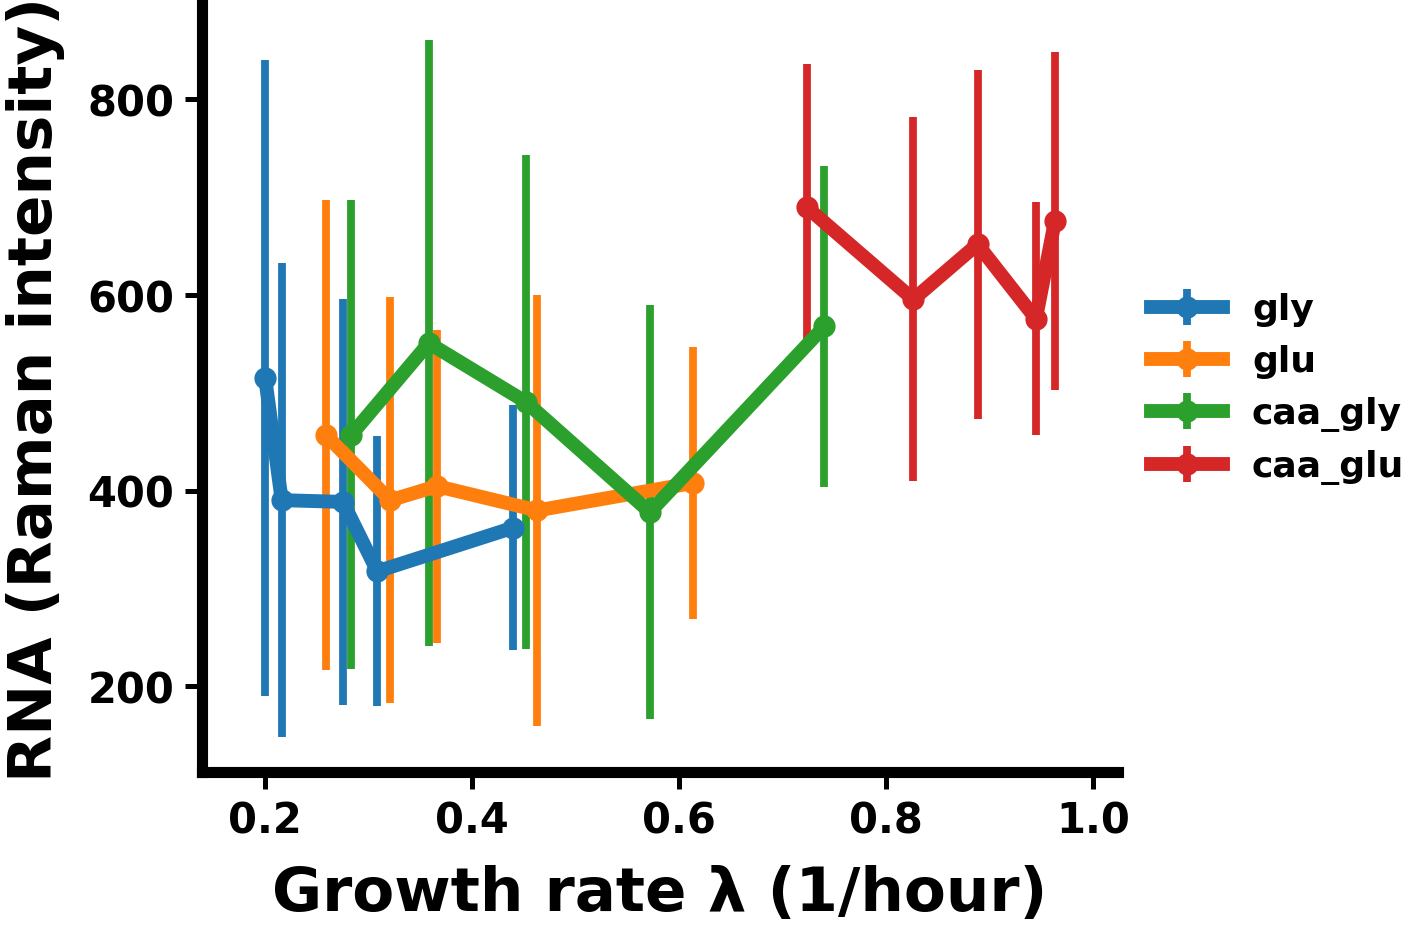

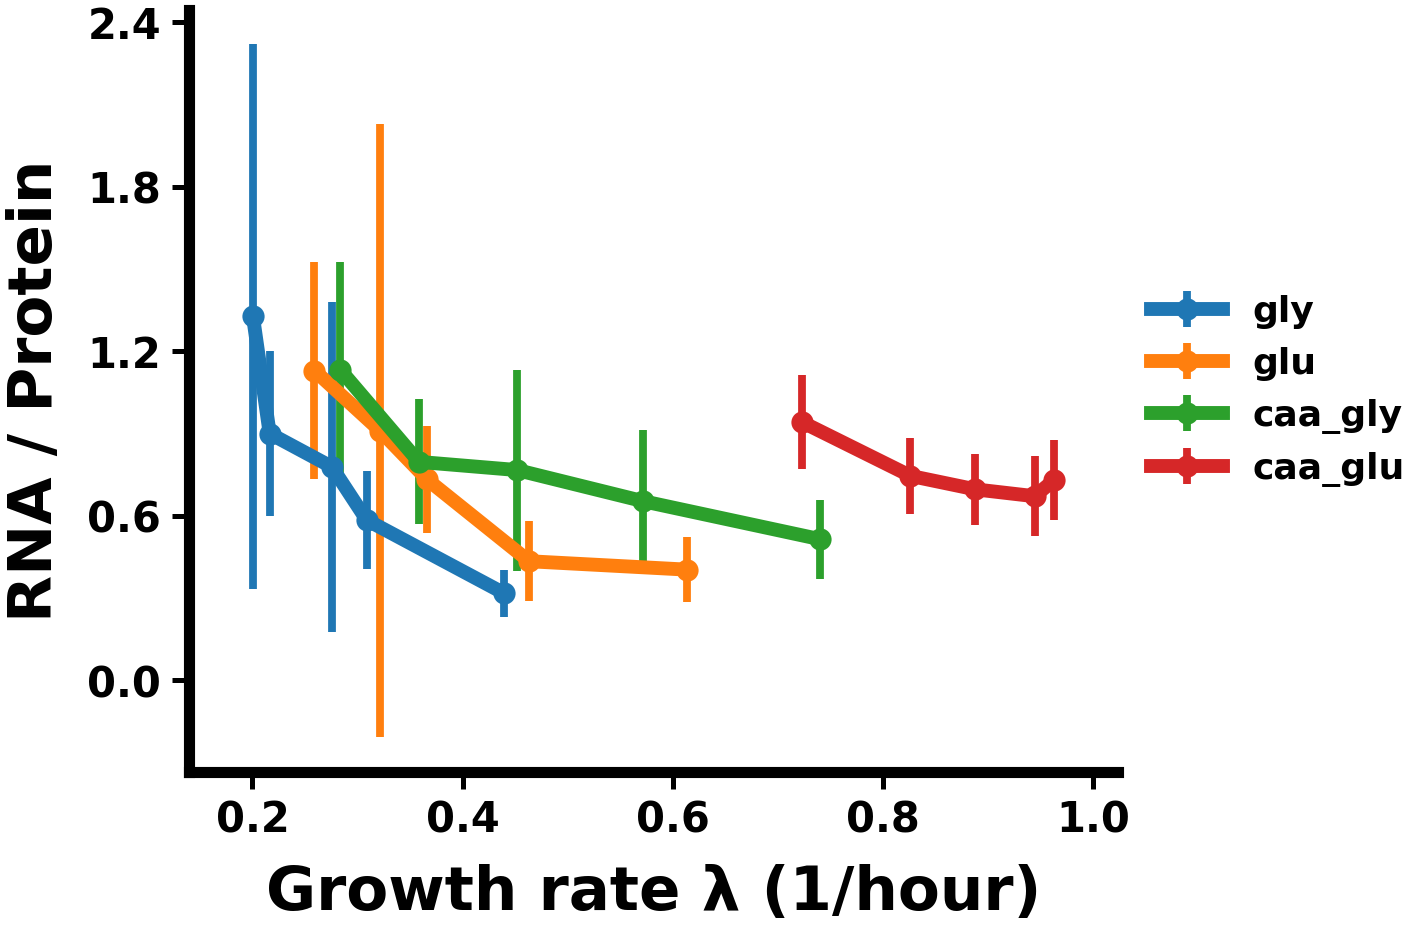

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.style.use("default")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (7.2, 4.7),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 16,
    "axes.labelsize": 22,
    "axes.titlesize": 22,
    "axes.linewidth": 4.0,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 13,
    "legend.frameon": False,
    "lines.linewidth": 5,
    "lines.markersize": 8,
    "errorbar.capsize": 4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03
})

SHOW_LEGEND = True

rna_df = pd.read_csv("../Data/RamanData/rna.csv")
protein_df = pd.read_csv("../Data/RamanData/protein.csv")
growth_df = pd.read_csv("../Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()
ABX_VALUES = sorted(growth_df["Dose"].unique())

records = []

for nutrient in nutrients:
    for dose in ABX_VALUES:
        col = f"Cm{dose}_{nutrient}"
        if col not in rna_df.columns:
            continue

        RNA_raw = rna_df[col].values
        PROT_raw = protein_df[col].values

        valid = (
            (~np.isnan(RNA_raw)) &
            (~np.isnan(PROT_raw)) &
            (RNA_raw > 0) &
            (PROT_raw > 0)
        )

        RNA = RNA_raw[valid]
        PROT = PROT_raw[valid]

        if len(RNA) < 3:
            continue

        ratio = RNA / PROT

        finite = np.isfinite(ratio)
        ratio = ratio[finite]
        RNA = RNA[finite]
        PROT = PROT[finite]

        mu_row = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == dose)
        ]

        if len(mu_row) == 0:
            continue

        mu = mu_row["Value"].values[0]

        records.append({
            "Condition": nutrient,
            "Dose": dose,
            "mu": mu,
            "RNA_mean": np.mean(RNA),
            "RNA_sd": np.std(RNA),
            "PROT_mean": np.mean(PROT),
            "PROT_sd": np.std(PROT),
            "ratio_mean": np.mean(ratio),
            "ratio_sd": np.std(ratio)
        })

df_summary = pd.DataFrame(records)

model_color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
baseline = df_summary[df_summary["Dose"] == 0].sort_values("mu")
ordered_nutrients = baseline["Condition"].tolist()

nutrient_colors = {
    nutrient: model_color_cycle[i]
    for i, nutrient in enumerate(ordered_nutrients)
}

def finish_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, labelpad=8, weight='bold')
    ax.set_ylabel(ylabel, labelpad=8, weight='bold')
    ax.tick_params(direction="out", length=6, width=1.8, pad=4)
    ax.margins(x=0.08, y=0.05)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    fig = ax.figure
    fig.tight_layout(pad=0.25)
    if SHOW_LEGEND:
        fig.subplots_adjust(right=0.78)

def plot_vs_abx(df, ycol, yerrcol, ylabel, filename, growth_plot=False):
    fig, ax = plt.subplots()
    for nutrient in ordered_nutrients:
        subset = df[df["Condition"] == nutrient].sort_values("Dose")
        if growth_plot:
            ax.plot(
                subset["Dose"],
                subset[ycol],
                "-o",
                color=nutrient_colors[nutrient],
                label=nutrient
            )
        else:
            ax.errorbar(
                subset["Dose"],
                subset[ycol],
                yerr=subset[yerrcol],
                fmt="-o",
                color=nutrient_colors[nutrient],
                elinewidth=2.8,
                capthick=2.8,
                markeredgewidth=0,
                label=nutrient
            )
    finish_axes(ax, "Chloramphenicol concentration (µM)", ylabel)
    if SHOW_LEGEND:
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            handlelength=2.0
        )
    fig.savefig(filename)
    ax.set_xticks([0,2,4,6,8,10,12])
    plt.show()

def plot_vs_growth(df, ycol, yerrcol, ylabel, filename):
    fig, ax = plt.subplots()
    for nutrient in ordered_nutrients:
        subset = df[df["Condition"] == nutrient].sort_values("mu")
        ax.errorbar(
            subset["mu"],
            subset[ycol],
            yerr=subset[yerrcol],
            fmt="-o",
            color=nutrient_colors[nutrient],
            elinewidth=2.8,
            capthick=2.8,
            markeredgewidth=0,
            label=nutrient
        )
    finish_axes(ax, "Growth rate λ (1/hour)", ylabel)
    if SHOW_LEGEND:
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            handlelength=2.0
        )
    fig.savefig(filename)
    plt.show()

plot_vs_abx(df_summary, "mu", None, "Growth rate λ (1/hour)", "raman_growth_vs_abx.png", growth_plot=True)
plot_vs_abx(df_summary, "RNA_mean", "RNA_sd", "RNA (Raman intensity)", "raman_rna_vs_abx.png")
plot_vs_abx(df_summary, "ratio_mean", "ratio_sd", "RNA / Protein", "raman_ratio_vs_abx.png")
plot_vs_abx(df_summary, "PROT_mean", "PROT_sd", "Protein (Raman intensity)", "raman_protein_vs_abx.png")

plot_vs_growth(df_summary, "PROT_mean", "PROT_sd", "Protein (Raman intensity)", "raman_protein_vs_growth.png")
plot_vs_growth(df_summary, "RNA_mean", "RNA_sd", "RNA (Raman intensity)", "raman_rna_vs_growth.png")
plot_vs_growth(df_summary, "ratio_mean", "ratio_sd", "RNA / Protein", "raman_ratio_vs_growth.png")

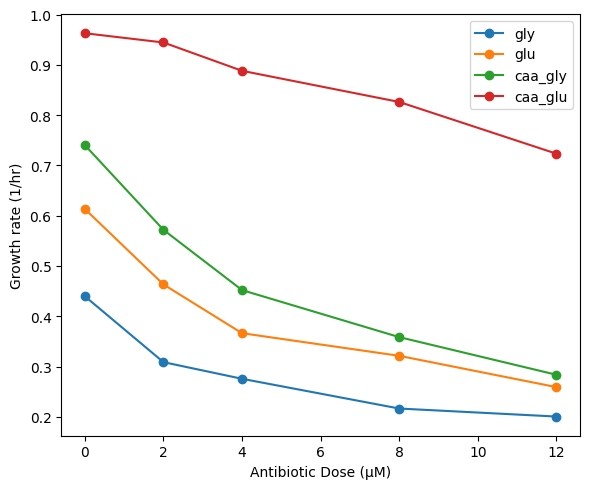

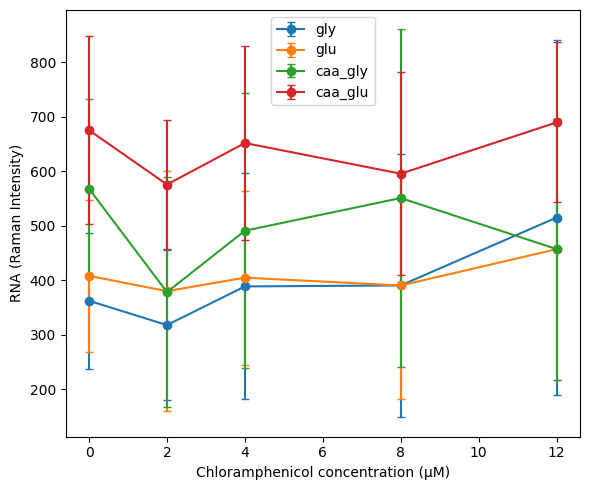

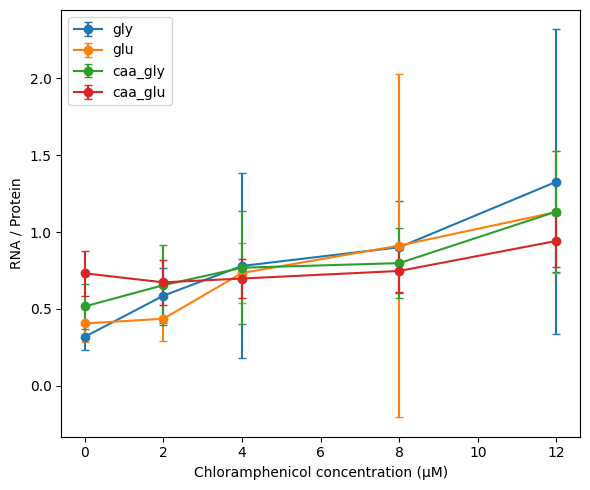

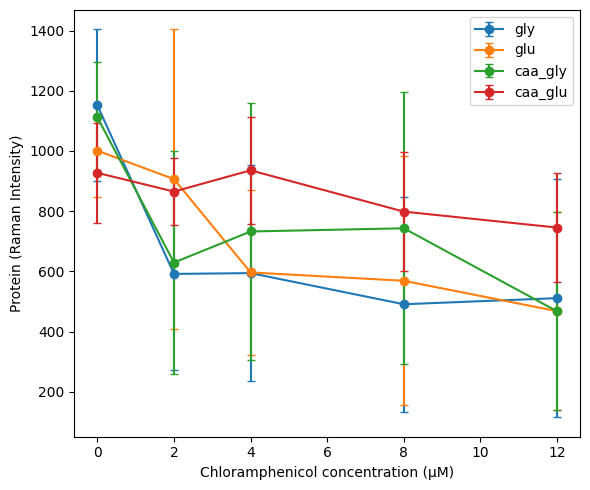

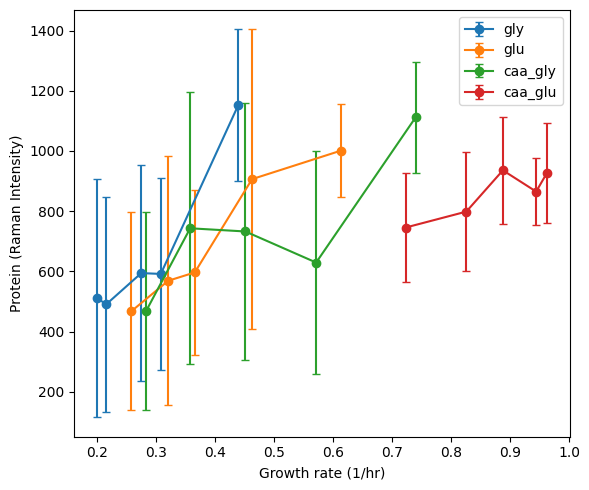

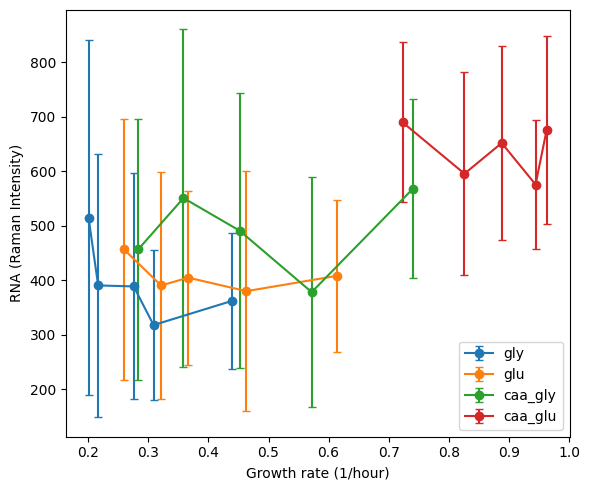

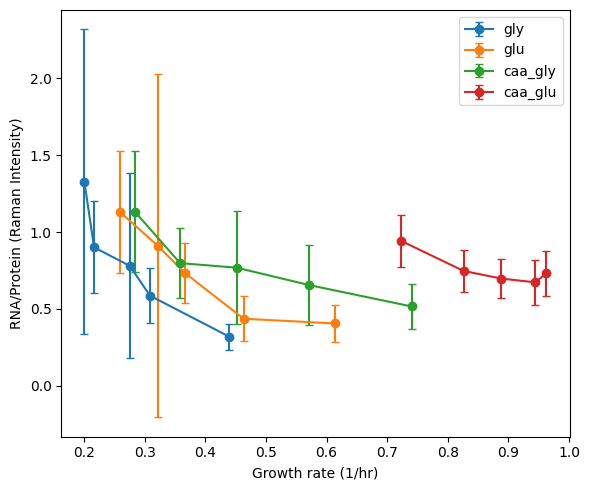

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plt.style.use("default")


rna_df = pd.read_csv("../Data/RamanData/rna.csv")
protein_df = pd.read_csv("../Data/RamanData/protein.csv")
growth_df = pd.read_csv("../Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()
ABX_VALUES = sorted(growth_df["Dose"].unique())

# BUILD SUMMARY PER NUTRIENT

records = []

for nutrient in nutrients:
    for dose in ABX_VALUES:

        col = f"Cm{dose}_{nutrient}"
        if col not in rna_df.columns:
            continue

        RNA_raw  = rna_df[col].values
        PROT_raw = protein_df[col].values

        # Strict filtering
        valid = (
            (~np.isnan(RNA_raw)) &
            (~np.isnan(PROT_raw)) &
            (RNA_raw > 0) &
            (PROT_raw > 0)
        )

        RNA  = RNA_raw[valid]
        PROT = PROT_raw[valid]

        if len(RNA) < 3:
            continue

        ratio = RNA / PROT

        # Remove any infinities just in case
        finite = np.isfinite(ratio)
        ratio = ratio[finite]
        RNA   = RNA[finite]
        PROT  = PROT[finite]

        mu_row = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == dose)
        ]

        if len(mu_row) == 0:
            continue

        mu = mu_row["Value"].values[0]

        records.append({
            "Condition": nutrient,
            "Dose": dose,
            "mu": mu,
            "RNA_mean": np.mean(RNA),
            "RNA_sd": np.std(RNA),
            "PROT_mean": np.mean(PROT),
            "PROT_sd": np.std(PROT),
            "ratio_mean": np.mean(ratio),
            "ratio_sd": np.std(ratio) #/ np.sqrt(len(ratio))
        })

df_summary = pd.DataFrame(records)

# MATCH MODEL COLOURS
model_color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
baseline = df_summary[df_summary["Dose"] == 0].sort_values("mu")
ordered_nutrients = baseline["Condition"].tolist()

nutrient_colors = {
    nutrient: model_color_cycle[i]
    for i, nutrient in enumerate(ordered_nutrients)
}

# PLOT 1 — Growth vs Antibiotic
plt.figure(figsize=(6,5))

for nutrient in ordered_nutrients:
    subset = df_summary[df_summary["Condition"] == nutrient]
    plt.plot(
        subset["Dose"],
        subset["mu"],
        marker='o',
        color=nutrient_colors[nutrient],
        label=nutrient
    )

plt.xlabel("Antibiotic Dose (µM)")
plt.ylabel("Growth rate (1/hr)")
# plt.title("Growth vs Antibiotic (Raman)")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 2 — RNA vs Antibiotic
plt.figure(figsize=(6,5))

for nutrient in ordered_nutrients:
    subset = df_summary[df_summary["Condition"] == nutrient]
    plt.errorbar(
        subset["Dose"],
        subset["RNA_mean"],
        yerr=subset["RNA_sd"],
        marker='o',
        capsize=3,
        color=nutrient_colors[nutrient],
        label=nutrient
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("RNA (Raman Intensity)")
# plt.title("RNA vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 3 — RNA/Protein vs Antibiotic
plt.figure(figsize=(6,5))

for nutrient in ordered_nutrients:
    subset = df_summary[df_summary["Condition"] == nutrient]
    plt.errorbar(
        subset["Dose"],
        subset["ratio_mean"],
        yerr=subset["ratio_sd"],
        marker='o',
        capsize=3,
        color=nutrient_colors[nutrient],
        label=nutrient
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("RNA / Protein")
# plt.title("RNA/Protein vs Antibiotic")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 4 — Protein vs Antibiotic
plt.figure(figsize=(6,5))

for nutrient in ordered_nutrients:
    subset = df_summary[df_summary["Condition"] == nutrient]
    plt.errorbar(
        subset["Dose"],
        subset["PROT_mean"],
        yerr=subset["PROT_sd"],
        marker='o',
        capsize=3,
        color=nutrient_colors[nutrient],
        label=nutrient
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("Protein (Raman Intensity)")
# plt.title("Protein vs Growth")
plt.legend()
plt.tight_layout()
plt.show()



# PLOT 4 — Protein vs Growth
plt.figure(figsize=(6,5))

for nutrient in ordered_nutrients:
    subset = df_summary[df_summary["Condition"] == nutrient]
    plt.errorbar(
        subset["mu"],
        subset["PROT_mean"],
        yerr=subset["PROT_sd"],
        marker='o',
        capsize=3,
        color=nutrient_colors[nutrient],
        label=nutrient
    )

plt.xlabel("Growth rate (1/hr)")
plt.ylabel("Protein (Raman Intensity)")
# plt.title("Protein vs Growth")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 5 — RNA vs Growth
plt.figure(figsize=(6,5))

for nutrient in ordered_nutrients:
    subset = df_summary[df_summary["Condition"] == nutrient]
    plt.errorbar(
        subset["mu"],
        subset["RNA_mean"],
        yerr=subset["RNA_sd"],
        marker='o',
        capsize=3,
        color=nutrient_colors[nutrient],
        label=nutrient
    )

plt.xlabel("Growth rate (1/hour)")
plt.ylabel("RNA (Raman Intensity)")
# plt.title("RNA vs Growth (Raman)")
plt.legend()
plt.tight_layout()
plt.show()

# PLOT 4 — Ratio vs Growth
plt.figure(figsize=(6,5))

for nutrient in ordered_nutrients:
    subset = df_summary[df_summary["Condition"] == nutrient]
    plt.errorbar(
        subset["mu"],
        subset["ratio_mean"],
        yerr=subset["ratio_sd"],
        marker='o',
        capsize=3,
        color=nutrient_colors[nutrient],
        label=nutrient
    )

plt.xlabel("Growth rate (1/hr)")
plt.ylabel("RNA/Protein (Raman Intensity)")
# plt.title("Protein vs Growth")
plt.legend()
plt.tight_layout()
plt.show()

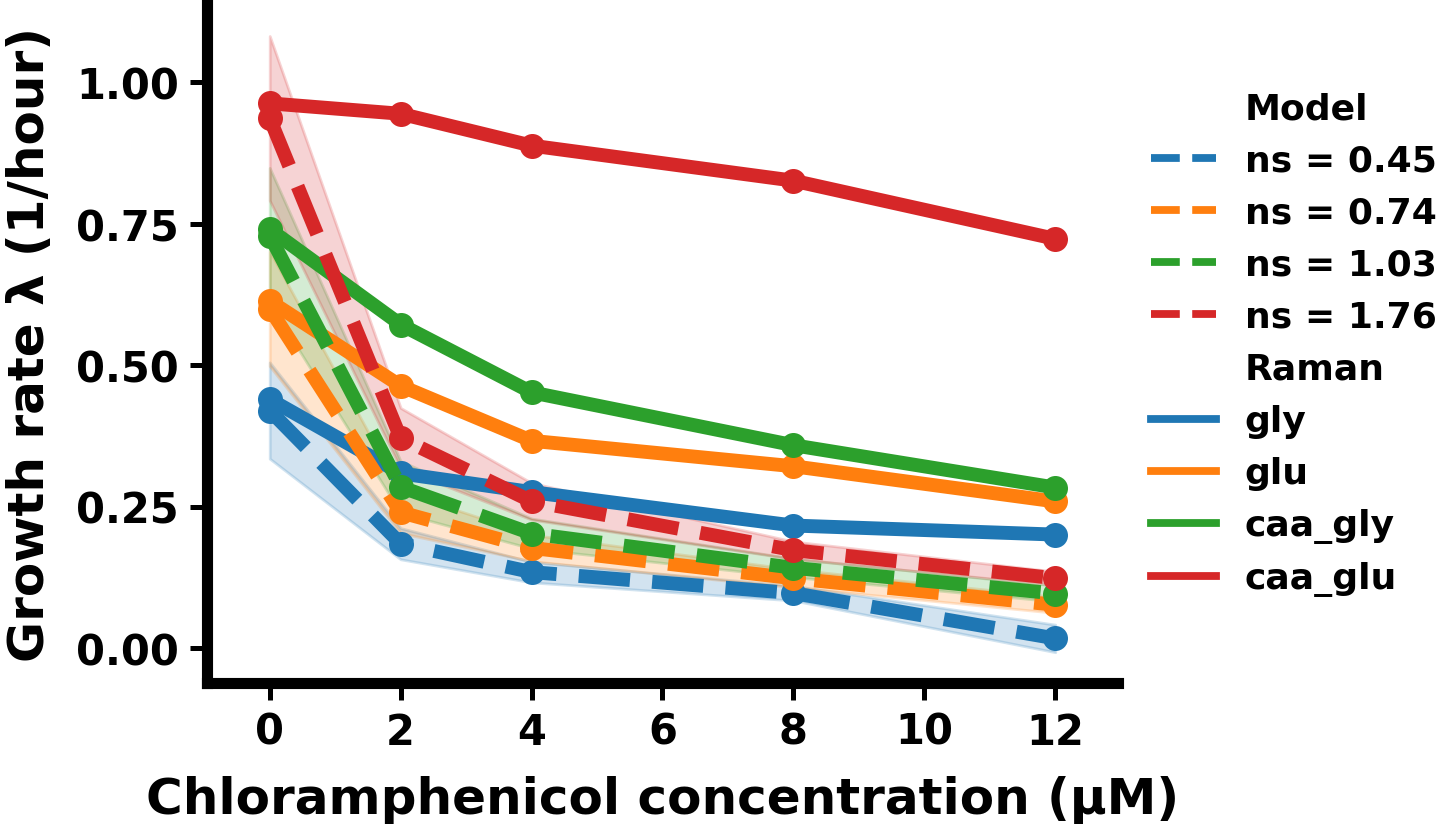

In [78]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

plt.style.use("default")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "axes.linewidth": 4.0,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 13,
    "legend.frameon": False,
    "lines.linewidth": 4,
    "lines.markersize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03
})

ordered_nutrients = ["gly", "glu", "caa_gly", "caa_glu"]

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

nutrient_colors = {
    nutrient: base_colors[i]
    for i, nutrient in enumerate(ordered_nutrients)
}

nutrient_to_ns = {
    "gly": 0.45,
    "glu": 0.74,
    "caa_gly": 1.03,
    "caa_glu": 1.76
}

pretty_names = {
    "gly": "gly",
    "glu": "glu",
    "caa_gly": "caa_gly",
    "caa_glu": "caa_glu"
}

def finish_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, labelpad=8, weight='bold')
    ax.set_ylabel(ylabel, labelpad=8, weight='bold')
    ax.tick_params(direction="out", length=6, width=1.8, pad=4)
    ax.margins(x=0.08, y=0.05)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    fig = ax.figure
    fig.tight_layout(pad=0.25)
    fig.subplots_adjust(right=0.78)

fig, ax = plt.subplots()

for nutrient in ordered_nutrients:
    color = nutrient_colors[nutrient]

    raman_subset = df_summary[df_summary["Condition"] == nutrient].sort_values("Dose")
    ax.plot(
        raman_subset["Dose"],
        raman_subset["mu"],
        marker="o",
        linestyle="-",
        color=color,
        linewidth=5
    )

    ns_val = nutrient_to_ns[nutrient]
    model_subset = df_model[df_model["ns"] == ns_val].sort_values("abx")
    ax.plot(
        model_subset["abx"],
        model_subset["mu_mean"],
        linestyle="--",
        marker="o",
        color=color,
        linewidth=5
    )

    ax.fill_between(
        model_subset["abx"],
        model_subset["mu_mean"] - model_subset["mu_sd"],
        model_subset["mu_mean"] + model_subset["mu_sd"],
        color=color,
        alpha=0.2
    )

finish_axes(ax, "Chloramphenicol concentration (µM)", "Growth rate λ (1/hour)")

from matplotlib.lines import Line2D

model_handles = [
    Line2D([0], [0], color=nutrient_colors[n], lw=2.8, linestyle="--", label=f"ns = {nutrient_to_ns[n]:.2f}")
    for n in ordered_nutrients
]

raman_handles = [
    Line2D([0], [0], color=nutrient_colors[n], lw=2.8, linestyle="-", label=pretty_names[n])
    for n in ordered_nutrients
]

heading_model = Line2D([], [], color="none", label="Model")
heading_raman = Line2D([], [], color="none", label="Raman")

all_handles = [heading_model] + model_handles + [heading_raman] + raman_handles

legend = ax.legend(
    handles=all_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    handlelength=1.8
)

for text, handle in zip(legend.get_texts(), all_handles):
    if handle.get_color() == "none":
        text.set_weight("bold")
        
ax.set_xticks([0,2,4,6,8,10,12])

fig.savefig("growth_vs_abx_model_vs_raman.png")
plt.show()

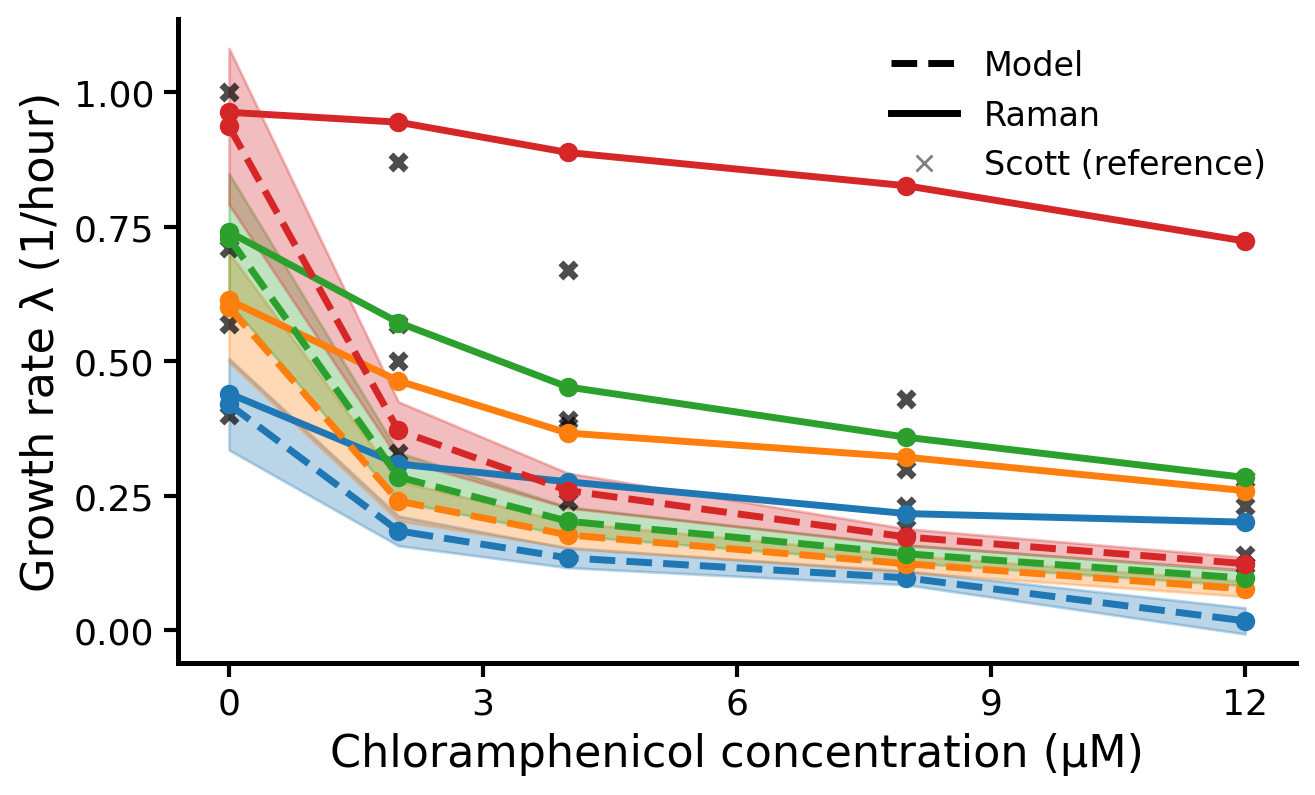

In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (6.8, 4.2),
    "figure.dpi": 200,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.linewidth": 1.8,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False
})

fig, ax = plt.subplots()

ordered_nutrients = ["gly", "glu", "caa_gly", "caa_glu"]
base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

nutrient_colors = {
    nutrient: base_colors[i]
    for i, nutrient in enumerate(ordered_nutrients)
}

nutrient_to_ns = {
    "gly": 0.45,
    "glu": 0.74,
    "caa_gly": 1.03,
    "caa_glu": 1.76
}

for nutrient in ordered_nutrients:
    color = nutrient_colors[nutrient]

    raman = df_summary[df_summary["Condition"] == nutrient].sort_values("Dose")
    ax.plot(raman["Dose"], raman["mu"], marker="o", linestyle="-", color=color)

    ns_val = nutrient_to_ns[nutrient]
    model = df_model[df_model["ns"] == ns_val].sort_values("abx")

    ax.plot(model["abx"], model["mu_mean"], linestyle="--", marker="o", color=color)

    ax.fill_between(
        model["abx"],
        model["mu_mean"] - model["mu_sd"],
        model["mu_mean"] + model["mu_sd"],
        color=color,
        alpha=0.3
    )

scott = pd.read_csv("../Data/Scott_Data.csv")
scott["lambda"] *= 60

SCOTT_KEEP = [0.08, 0.11542, 0.16651, 0.24022]

for ns_val in SCOTT_KEEP:
    sub = scott[scott["ns"] == ns_val].sort_values("cl")

    ax.scatter(
        sub["cl"],
        sub["lambda"],
        marker="x",
        color="black",
        alpha=0.7,
        s=30
    )

ax.set_xlabel("Chloramphenicol concentration (µM)")
ax.set_ylabel("Growth rate λ (1/hour)")

ax.xaxis.set_major_locator(MaxNLocator(5))
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.tick_params(direction="out", length=5, width=1.5)

legend_elements = [
    Line2D([0], [0], color="black", lw=2.5, linestyle="--", label="Model"),
    Line2D([0], [0], color="black", lw=2.5, linestyle="-", label="Raman"),
    Line2D([0], [0], color="black", lw=1.5, linestyle="", marker="x",
           label="Scott (reference)", alpha=0.5)
]

ax.legend(handles=legend_elements, frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("growth_clean.png", dpi=600)
plt.show()

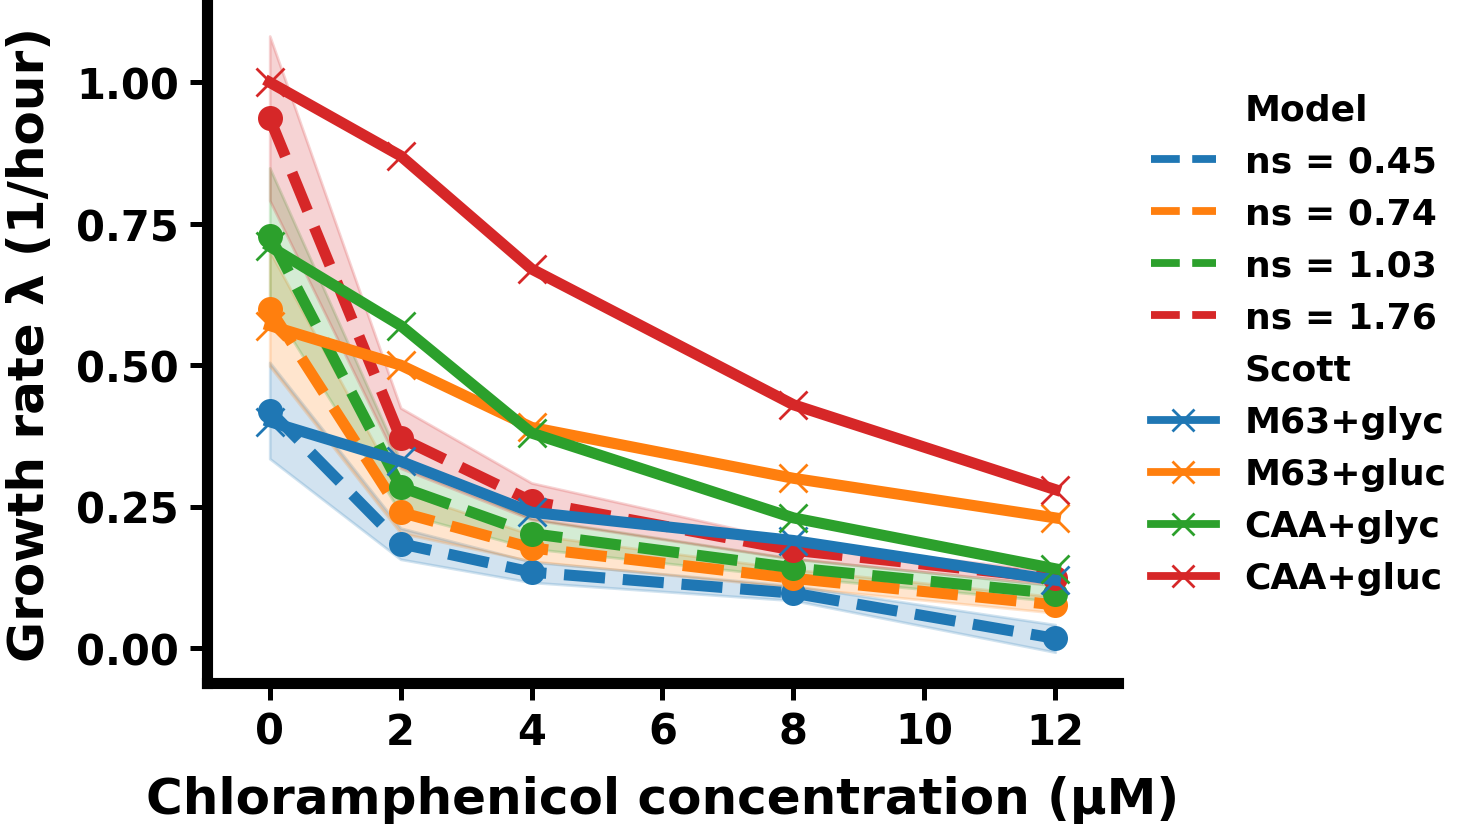

In [61]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

plt.style.use("default")

plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "axes.linewidth": 4.0,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 13,
    "legend.frameon": False,
    "lines.linewidth": 4,
    "lines.markersize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03
})

ordered_nutrients = ["gly", "glu", "caa_gly", "caa_glu"]

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

nutrient_colors = {
    nutrient: base_colors[i]
    for i, nutrient in enumerate(ordered_nutrients)
}

nutrient_to_ns = {
    "gly": 0.45,
    "glu": 0.74,
    "caa_gly": 1.03,
    "caa_glu": 1.76
}

def finish_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, labelpad=8, weight='bold')
    ax.set_ylabel(ylabel, labelpad=8, weight='bold')
    ax.tick_params(direction="out", length=6, width=1.8, pad=4)
    ax.margins(x=0.08, y=0.05)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    fig = ax.figure
    fig.tight_layout(pad=0.25)
    fig.subplots_adjust(right=0.78)

fig, ax = plt.subplots()

# MODEL
for nutrient in ordered_nutrients:
    color = nutrient_colors[nutrient]

    ns_val = nutrient_to_ns[nutrient]
    model_subset = df_model[df_model["ns"] == ns_val].sort_values("abx")

    ax.plot(
        model_subset["abx"],
        model_subset["mu_mean"],
        linestyle="--",
        marker="o",
        color=color
    )

    ax.fill_between(
        model_subset["abx"],
        model_subset["mu_mean"] - model_subset["mu_sd"],
        model_subset["mu_mean"] + model_subset["mu_sd"],
        color=color,
        alpha=0.2
    )

# SCOTT
scott = pd.read_csv("../Data/Scott_Data.csv")
scott["lambda"] *= 60

SCOTT_KEEP = [0.08, 0.11542, 0.16651, 0.24022]

scott_ns_to_model = {
    0.08: 0.45,
    0.11542: 0.74,
    0.16651: 1.03,
    0.24022: 1.76
}
scott_labels = {
    0.08: "M63+glyc",
    0.11542: "M63+gluc",
    0.16651: "CAA+glyc",
    0.24022: "CAA+gluc"
}

scott_color_map = {}

for ns_val in SCOTT_KEEP:
    sub = scott[scott["ns"] == ns_val].sort_values("cl")

    nutrient = [k for k, v in nutrient_to_ns.items() if v == scott_ns_to_model[ns_val]][0]
    color = nutrient_colors[nutrient]

    scott_color_map[ns_val] = color

    ax.plot(
        sub["cl"],
        sub["lambda"],
        linestyle="-",
        marker="x",
        color=color,
        markersize=10
    )

finish_axes(ax, "Chloramphenicol concentration (µM)", "Growth rate λ (1/hour)")

# LEGEND
model_handles = [
    Line2D([0], [0], color=nutrient_colors[n], lw=2.8, linestyle="--", label=f"ns = {nutrient_to_ns[n]:.2f}")
    for n in ordered_nutrients
]

scott_handles = [
    Line2D([0], [0],
           color=scott_color_map[ns],
           lw=2.8,
           linestyle="-",
           marker="x",
           label=scott_labels[ns])
    for ns in SCOTT_KEEP
]

heading_model = Line2D([], [], color="none", label="Model")
heading_scott = Line2D([], [], color="none", label="Scott")

all_handles = [heading_model] + model_handles + [heading_scott] + scott_handles

legend = ax.legend(
    handles=all_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    handlelength=1.8
)

ax.set_xticks([0,2,4,6,8,10,12])

fig.savefig("growth_vs_abx_model_vs_scott.png")
plt.show()

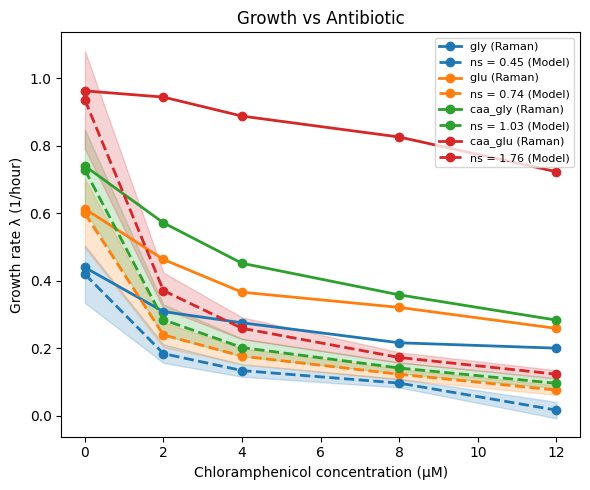

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("default")

ordered_nutrients = ["gly", "glu", "caa_gly", "caa_glu"]

base_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

nutrient_colors = {
    nutrient: base_colors[i]
    for i, nutrient in enumerate(ordered_nutrients)
}

nutrient_to_ns = {
    "gly": 0.45,
    "glu": 0.74,
    "caa_gly": 1.03,
    "caa_glu": 1.76
}

plt.figure(figsize=(6,5))

for nutrient in ordered_nutrients:

    color = nutrient_colors[nutrient]

    # Raman (solid)
    raman_subset = df_summary[df_summary["Condition"] == nutrient]
    raman_subset = raman_subset.sort_values("Dose")

    plt.plot(
        raman_subset["Dose"],
        raman_subset["mu"],
        marker='o',
        linestyle='-',
        color=color,
        linewidth=2,
        label=f"{nutrient} (Raman)"
    )

    # Model (dashed)
    ns_val = nutrient_to_ns[nutrient]
    model_subset = df_model[df_model["ns"] == ns_val]
    model_subset = model_subset.sort_values("abx")

    # plt.errorbar(
    #     model_subset["abx"],
    #     model_subset["mu_mean"],
    #     yerr=model_subset["mu_sd"],
    #     marker='o',
    #     linestyle='--',
    #     color=color,
    #     linewidth=2,
    #     label=f"ns = {ns_val} (Model)"
    # )
    plt.plot(
        model_subset["abx"],
        model_subset["mu_mean"],
        linestyle='--',
        marker='o',
        color=color,
        linewidth=2,
        label=f"ns = {ns_val} (Model)"
    )

    plt.fill_between(
        model_subset["abx"],
        model_subset["mu_mean"] - model_subset["mu_sd"],
        model_subset["mu_mean"] + model_subset["mu_sd"],
        color=color,
        alpha=0.2
    )

plt.xlabel("Chloramphenicol concentration (µM)")
plt.ylabel("Growth rate λ (1/hour)")
plt.title("Growth vs Antibiotic")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

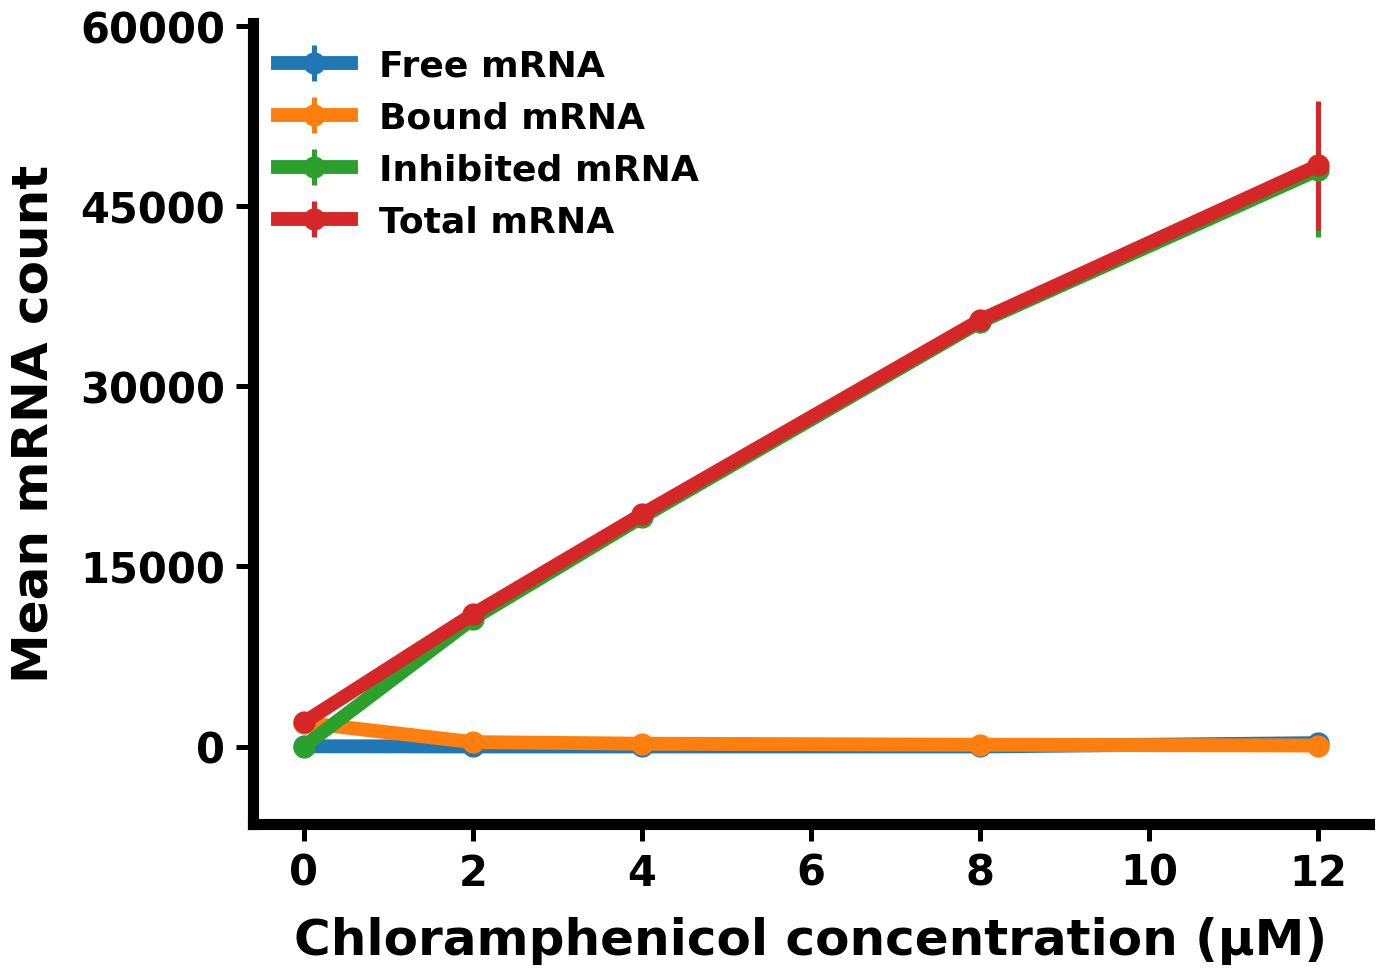

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
from matplotlib.ticker import MaxNLocator

plt.style.use("default")
plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (7.2, 5.2),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "axes.linewidth": 4.0,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 13,
    "legend.frameon": False,
    "lines.linewidth": 5,
    "lines.markersize": 8,
    "errorbar.capsize": 4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05
})

NS_VALUES = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mRNA_states(df):
    free_mRNA = (
        df["mm(t)"] +
        df["mt(t)"] +
        df["mq(t)"] +
        df["mr(t)"]
    ).to_numpy()

    bound_mRNA = (
        df["rmm(t)"] +
        df["rmt(t)"] +
        df["rmq(t)"] +
        df["rmr(t)"]
    ).to_numpy()

    inhibited_mRNA = (
        df["zmm(t)"] +
        df["zmt(t)"] +
        df["zmq(t)"] +
        df["zmr(t)"]
    ).to_numpy()

    return free_mRNA, bound_mRNA, inhibited_mRNA

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:
        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        free_m, bound_m, inhib_m = compute_mRNA_states(df)

        records.append({
            "ns": ns,
            "abx": abx,
            "free_mean": np.mean(free_m),
            "bound_mean": np.mean(bound_m),
            "inhib_mean": np.mean(inhib_m),
            "total_mean": np.mean(free_m + bound_m + inhib_m)
        })

df_mrna = pd.DataFrame(records)

df_abx = df_mrna.groupby("abx").agg({
    "free_mean": ["mean", "std"],
    "bound_mean": ["mean", "std"],
    "inhib_mean": ["mean", "std"],
    "total_mean": ["mean", "std"]
}).reset_index()

df_abx.columns = [
    "Dose",
    "free_mean", "free_sd",
    "bound_mean", "bound_sd",
    "inhib_mean", "inhib_sd",
    "total_mean", "total_sd"
]

def finish_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, labelpad=8, weight='bold')
    ax.set_ylabel(ylabel, labelpad=8, weight='bold')
    ax.tick_params(direction="out", length=6, width=1.8, pad=4)
    ax.margins(x=0.05, y=0.12)
    ax.set_xticks([0,2,4,6,8,10,12])
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

fig, ax = plt.subplots()

ax.errorbar(
    df_abx["Dose"], df_abx["free_mean"],
    yerr=df_abx["free_sd"],
    fmt="-o",
    elinewidth=1.8,
    capthick=1.8,
    markeredgewidth=0,
    label="Free mRNA"
)

ax.errorbar(
    df_abx["Dose"], df_abx["bound_mean"],
    yerr=df_abx["bound_sd"],
    fmt="-o",
    elinewidth=1.8,
    capthick=1.8,
    markeredgewidth=0,
    label="Bound mRNA"
)

ax.errorbar(
    df_abx["Dose"], df_abx["inhib_mean"],
    yerr=df_abx["inhib_sd"],
    fmt="-o",
    elinewidth=1.8,
    capthick=1.8,
    markeredgewidth=0,
    label="Inhibited mRNA"
)

ax.errorbar(
    df_abx["Dose"], df_abx["total_mean"],
    yerr=df_abx["total_sd"],
    fmt="-o",
    elinewidth=1.8,
    capthick=1.8,
    markeredgewidth=0,
    label="Total mRNA"
)

finish_axes(ax, "Chloramphenicol concentration (µM)", "Mean mRNA count")
ax.legend(loc="best", handlelength=2.0, borderaxespad=0.3)

# fig.subplots_adjust(left=0.15, right=0.97, bottom=0.16, top=0.97)
fig.savefig("mrna_state_distribution_vs_abx.png")
plt.show()

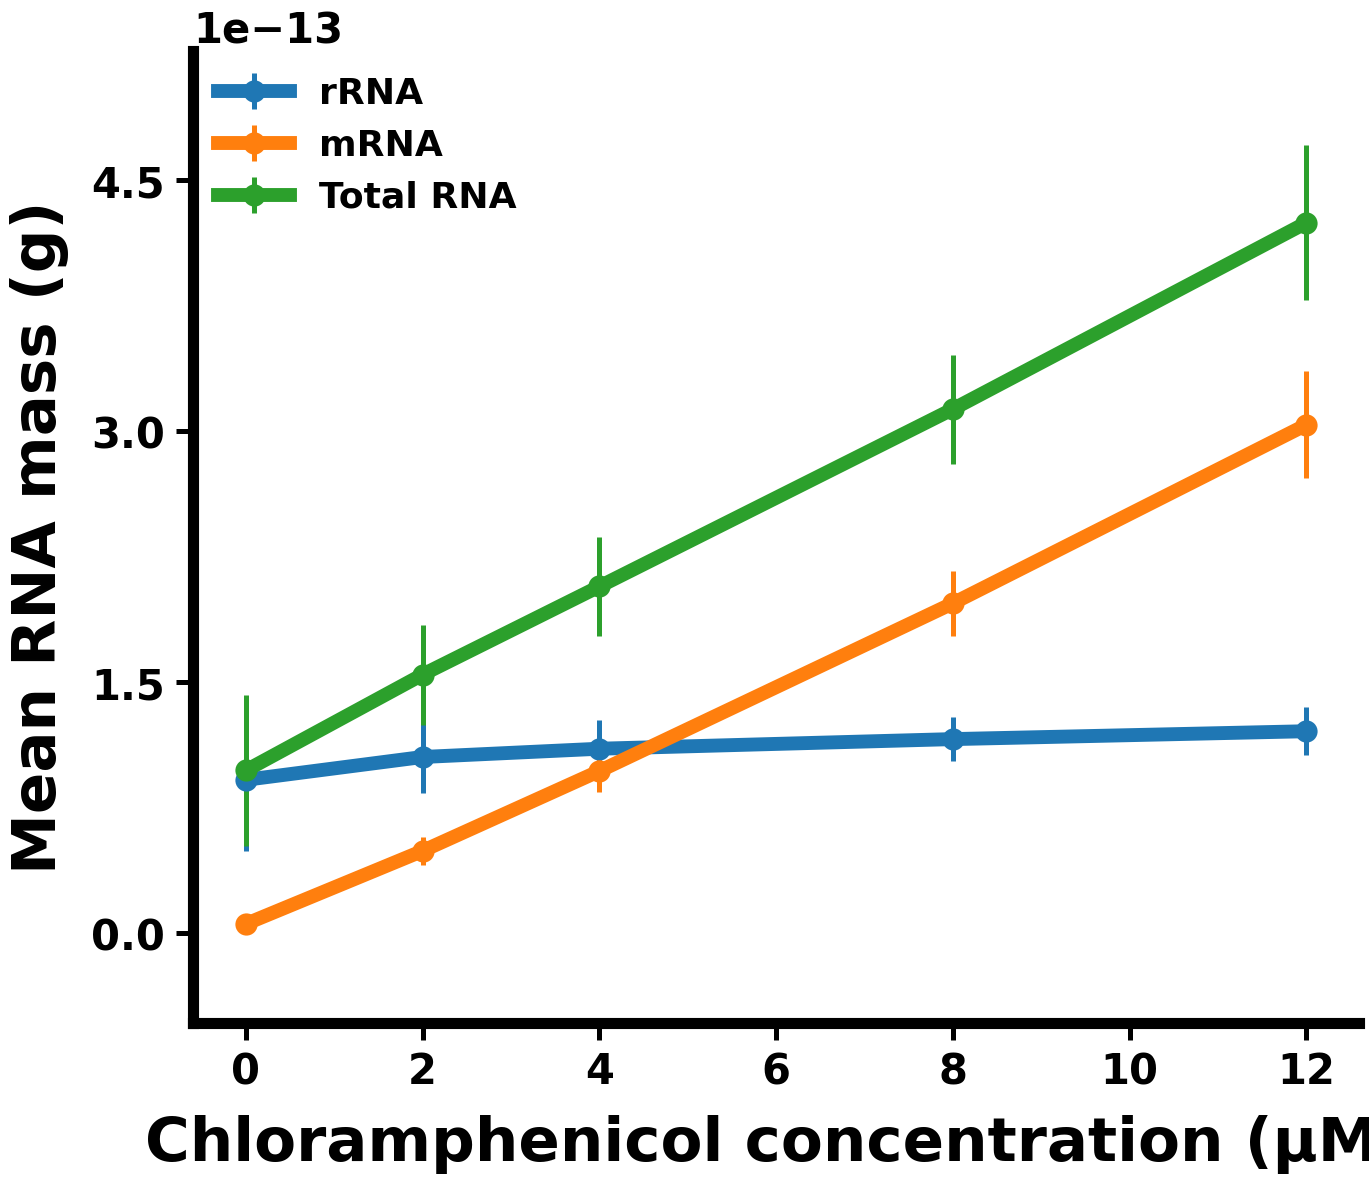

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
from matplotlib.ticker import MaxNLocator

plt.style.use("default")

plt.rcParams['font.weight'] = 'bold'
plt.rcParams.update({
    "figure.figsize": (7.2, 6),
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "font.size": 16,
    "axes.labelsize": 22,
    "axes.titlesize": 22,
    "axes.linewidth": 4.0,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "xtick.major.width": 1.8,
    "ytick.major.width": 1.8,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "legend.fontsize": 13,
    "legend.frameon": False,
    "lines.linewidth": 5,
    "lines.markersize": 8,
    "errorbar.capsize": 4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05
})

NS_VALUES = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q = df["q(t)"].to_numpy()
    et = df["et(t)"].to_numpy()
    em = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo = NX * (q + et + em)

    total_mass = ribo_mass + non_ribo
    return ribo_mass, total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    lam = (active * gamma / total_mass) * 60.0
    return lam

def compute_RNA_components(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    mRNA_nt = (mm + mt + mq + mr).to_numpy()

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

    rRNA_nt = r_tot * RIBO_RNA_NT

    mRNA_mass = (mRNA_nt / AVOGADRO) * MW_NT
    rRNA_mass = (rRNA_nt / AVOGADRO) * MW_NT

    return mRNA_mass, rRNA_mass

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:
        path = f"../Data/ns{int(ns*100):03d}/abx{abx}.arrow"
        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        mRNA_mass, rRNA_mass = compute_RNA_components(df)
        total_RNA_mass = mRNA_mass + rRNA_mass

        records.append({
            "ns": ns,
            "abx": abx,
            "mRNA_mean": np.mean(mRNA_mass),
            "rRNA_mean": np.mean(rRNA_mass),
            "total_RNA_mean": np.mean(total_RNA_mass)
        })

df_components = pd.DataFrame(records)

df_abx = df_components.groupby("abx").agg({
    "mRNA_mean": ["mean", "std"],
    "rRNA_mean": ["mean", "std"],
    "total_RNA_mean": ["mean", "std"]
}).reset_index()

df_abx.columns = [
    "Dose",
    "mRNA_mean", "mRNA_sd",
    "rRNA_mean", "rRNA_sd",
    "total_mean", "total_sd"
]

def finish_axes(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, labelpad=8, weight='bold')
    ax.set_ylabel(ylabel, labelpad=8, weight='bold')
    ax.tick_params(direction="out", length=6, width=1.8, pad=4)
    ax.margins(x=0.05, y=0.12)
    ax.set_xticks([0,2,4,6,8,10,12])
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

fig, ax = plt.subplots()

ax.errorbar(
    df_abx["Dose"], df_abx["rRNA_mean"],
    yerr=df_abx["rRNA_sd"],
    fmt="-o",
    elinewidth=1.8,
    capthick=1.8,
    markeredgewidth=0,
    label="rRNA"
)

ax.errorbar(
    df_abx["Dose"], df_abx["mRNA_mean"],
    yerr=df_abx["mRNA_sd"],
    fmt="-o",
    elinewidth=1.8,
    capthick=1.8,
    markeredgewidth=0,
    label="mRNA"
)

ax.errorbar(
    df_abx["Dose"], df_abx["total_mean"],
    yerr=df_abx["total_sd"],
    fmt="-o",
    elinewidth=1.8,
    capthick=1.8,
    markeredgewidth=0,
    label="Total RNA"
)

finish_axes(ax, "Chloramphenicol concentration (µM)", "Mean RNA mass (g)")
ax.legend(loc="best", handlelength=2.0, borderaxespad=0.3)

fig.subplots_adjust(left=0.16, right=0.97, bottom=0.16, top=0.97)
fig.savefig("rna_components_vs_abx.png")
plt.show()

In [ ]:
from scipy.stats import pearsonr, chi2
import numpy as np

df_model_corr = df_model.copy()

# Nutrient effect (within each antibiotic)

nutrient_rs = []
nutrient_ps = []

for abx in sorted(df_model_corr["abx"].unique()):
    subset = df_model_corr[df_model_corr["abx"] == abx]
    r, p = pearsonr(subset["mu_mean"], subset["ns"])
    nutrient_rs.append(r)
    nutrient_ps.append(p)

mean_r_nutrient = np.mean(np.abs(nutrient_rs))
mean_p_nutrient = np.mean(nutrient_ps)

# Fisher combined p
chi_stat_nut = -2 * np.sum(np.log(nutrient_ps))
combined_p_nutrient = 1 - chi2.cdf(chi_stat_nut, 2*len(nutrient_ps))

print("\nMODEL: Nutrient Effect")
for abx, r, p in zip(sorted(df_model_corr["abx"].unique()), nutrient_rs, nutrient_ps):
    print(f"abx = {abx}: r = {r:.3f}, p = {p:.3e}")

print(f"\nMean |r| = {mean_r_nutrient:.3f}")
print(f"Mean p = {mean_p_nutrient:.3e}")
print(f"Combined p (Fisher) = {combined_p_nutrient:.3e}")


# Antibiotic effect (within each nutrient)
abx_rs = []
abx_ps = []

for ns in sorted(df_model_corr["ns"].unique()):
    subset = df_model_corr[df_model_corr["ns"] == ns]
    r, p = pearsonr(subset["mu_mean"], subset["abx"])
    abx_rs.append(r)
    abx_ps.append(p)

mean_r_abx = np.mean(np.abs(abx_rs))
mean_p_abx = np.mean(abx_ps)

chi_stat_abx = -2 * np.sum(np.log(abx_ps))
combined_p_abx = 1 - chi2.cdf(chi_stat_abx, 2*len(abx_ps))

print("\nMODEL: Antibiotic Effect")
for ns, r, p in zip(sorted(df_model_corr["ns"].unique()), abx_rs, abx_ps):
    print(f"ns = {ns}: r = {r:.3f}, p = {p:.3e}")

print(f"\nMean |r| = {mean_r_abx:.3f}")
print(f"Mean p = {mean_p_abx:.3e}")
print(f"Combined p (Fisher) = {combined_p_abx:.3e}")


=== MODEL: Nutrient Effect ===
abx = 0: r = 0.981, p = 1.865e-02
abx = 2: r = 0.993, p = 6.706e-03
abx = 4: r = 0.989, p = 1.120e-02
abx = 8: r = 0.983, p = 1.692e-02
abx = 12: r = 0.906, p = 9.387e-02

Mean |r| = 0.971
Mean p = 2.947e-02
Combined p (Fisher) = 1.803e-05

=== MODEL: Antibiotic Effect ===
ns = 0.45: r = -0.869, p = 5.596e-02
ns = 0.74: r = -0.805, p = 9.996e-02
ns = 1.03: r = -0.793, p = 1.098e-01
ns = 1.76: r = -0.796, p = 1.071e-01

Mean |r| = 0.816
Mean p = 9.320e-02
Combined p (Fisher) = 1.354e-02


In [ ]:
from scipy.stats import pearsonr, chi2
import numpy as np

nutrient_to_ns = {
    "gly": 0.45,
    "glu": 0.74,
    "caa_gly": 1.03,
    "caa_glu": 1.76
}

df_raman_corr = df_summary.copy()
df_raman_corr["Nutrient_numeric"] = df_raman_corr["Condition"].map(nutrient_to_ns)

# Nutrient effect (within each antibiotic)
nutrient_rs = []
nutrient_ps = []

for dose in sorted(df_raman_corr["Dose"].unique()):
    subset = df_raman_corr[df_raman_corr["Dose"] == dose]
    r, p = pearsonr(subset["mu"], subset["Nutrient_numeric"])
    nutrient_rs.append(r)
    nutrient_ps.append(p)

mean_r_nutrient = np.mean(np.abs(nutrient_rs))
mean_p_nutrient = np.mean(nutrient_ps)

chi_stat_nut = -2 * np.sum(np.log(nutrient_ps))
combined_p_nutrient = 1 - chi2.cdf(chi_stat_nut, 2*len(nutrient_ps))

print("\nRAMAN: Nutrient Effect")
for dose, r, p in zip(sorted(df_raman_corr["Dose"].unique()), nutrient_rs, nutrient_ps):
    print(f"dose = {dose}: r = {r:.3f}, p = {p:.3e}")

print(f"\nMean |r| = {mean_r_nutrient:.3f}")
print(f"Mean p = {mean_p_nutrient:.3e}")
print(f"Combined p (Fisher) = {combined_p_nutrient:.3e}")


# Antibiotic effect (within each nutrient)
abx_rs = []
abx_ps = []

for nutrient in sorted(df_raman_corr["Condition"].unique()):
    subset = df_raman_corr[df_raman_corr["Condition"] == nutrient]
    r, p = pearsonr(subset["mu"], subset["Dose"])
    abx_rs.append(r)
    abx_ps.append(p)

mean_r_abx = np.mean(np.abs(abx_rs))
mean_p_abx = np.mean(abx_ps)

chi_stat_abx = -2 * np.sum(np.log(abx_ps))
combined_p_abx = 1 - chi2.cdf(chi_stat_abx, 2*len(abx_ps))

print("\nRAMAN: Antibiotic Effect")
for nutrient, r, p in zip(sorted(df_raman_corr["Condition"].unique()), abx_rs, abx_ps):
    print(f"{nutrient}: r = {r:.3f}, p = {p:.3e}")

print(f"\nMean |r| = {mean_r_abx:.3f}")
print(f"Mean p = {mean_p_abx:.3e}")
print(f"Combined p (Fisher) = {combined_p_abx:.3e}")


=== RAMAN: Nutrient Effect ===
dose = 0: r = 0.986, p = 1.356e-02
dose = 2: r = 0.999, p = 1.148e-03
dose = 4: r = 0.986, p = 1.379e-02
dose = 8: r = 0.975, p = 2.542e-02
dose = 12: r = 0.957, p = 4.313e-02

Mean |r| = 0.981
Mean p = 1.941e-02
Combined p (Fisher) = 2.861e-06

=== RAMAN: Antibiotic Effect ===
caa_glu: r = -0.993, p = 6.942e-04
caa_gly: r = -0.946, p = 1.495e-02
glu: r = -0.919, p = 2.735e-02
gly: r = -0.890, p = 4.293e-02

Mean |r| = 0.937
Mean p = 2.148e-02
Combined p (Fisher) = 1.455e-05


In [ ]:
import numpy as np
import pandas as pd

df_m = df_model.copy()

# Nutrient effect (within antibiotic)
delta_nutrient_model = []

for abx in sorted(df_m["abx"].unique()):
    subset = df_m[df_m["abx"] == abx]
    delta = subset["mu_mean"].max() - subset["mu_mean"].min()
    delta_nutrient_model.append(delta)

# Antibiotic effect (within nutrient)
delta_abx_model = []

for ns in sorted(df_m["ns"].unique()):
    subset = df_m[df_m["ns"] == ns]
    delta = subset["mu_mean"].max() - subset["mu_mean"].min()
    delta_abx_model.append(delta)

print("\nMODEL Δλ")
print(f"Nutrient effect: mean Δλ = {np.mean(delta_nutrient_model):.3f} ± {np.std(delta_nutrient_model):.3f}")
print(f"Antibiotic effect: mean Δλ = {np.mean(delta_abx_model):.3f} ± {np.std(delta_abx_model):.3f}")



# RAMAN 
df_r = df_summary.copy()

# Nutrient effect (within antibiotic)
delta_nutrient_raman = []

for dose in sorted(df_r["Dose"].unique()):
    subset = df_r[df_r["Dose"] == dose]
    delta = subset["mu"].max() - subset["mu"].min()
    delta_nutrient_raman.append(delta)

# Antibiotic effect (within nutrient)
delta_abx_raman = []

for nutrient in sorted(df_r["Condition"].unique()):
    subset = df_r[df_r["Condition"] == nutrient]
    delta = subset["mu"].max() - subset["mu"].min()
    delta_abx_raman.append(delta)

print("\nRAMAN Δλ")
print(f"Nutrient effect: mean Δλ = {np.mean(delta_nutrient_raman):.3f} ± {np.std(delta_nutrient_raman):.3f}")
print(f"Antibiotic effect: mean Δλ = {np.mean(delta_abx_raman):.3f} ± {np.std(delta_abx_raman):.3f}")


=== MODEL Δλ ===
Nutrient effect: mean Δλ = 0.202 ± 0.161
Antibiotic effect: mean Δλ = 0.593 ± 0.151

=== RAMAN Δλ ===
Nutrient effect: mean Δλ = 0.581 ± 0.048
Antibiotic effect: mean Δλ = 0.322 ± 0.091


In [ ]:
import numpy as np
import pandas as pd

df_m = df_model.copy()

print("\n MODEL")

# BASELINE NUTRIENT EFFECT (abx = 0)

baseline = df_m[df_m["abx"] == 0]

delta_nutrient_0 = baseline["mu_mean"].max() - baseline["mu_mean"].min()

print("\nBaseline (0 µM)")
print(f"Nutrient Δλ = {delta_nutrient_0:.3f}")

# EARLY ANTIBIOTIC EFFECT (0 to 2 µM)
delta_0_to_2 = []

for ns in sorted(df_m["ns"].unique()):
    lam0 = df_m[(df_m["ns"] == ns) & (df_m["abx"] == 0)]["mu_mean"].values[0]
    lam2 = df_m[(df_m["ns"] == ns) & (df_m["abx"] == 2)]["mu_mean"].values[0]
    delta_0_to_2.append(lam0 - lam2)

print("\nEarly antibiotic effect (0 to 2 µM)")
print(f"Mean Δλ = {np.mean(delta_0_to_2):.3f} ± {np.std(delta_0_to_2):.3f}")

# ESTABLISHED ANTIBIOTIC REGIME (2+ µM grouped)

df_m_2plus = df_m[df_m["abx"] >= 2]

delta_nutrient_2plus = []

for abx in sorted(df_m_2plus["abx"].unique()):
    subset = df_m_2plus[df_m_2plus["abx"] == abx]
    delta = subset["mu_mean"].max() - subset["mu_mean"].min()
    delta_nutrient_2plus.append(delta)

delta_abx_2plus = []

for ns in sorted(df_m_2plus["ns"].unique()):
    subset = df_m_2plus[df_m_2plus["ns"] == ns]
    delta = subset["mu_mean"].max() - subset["mu_mean"].min()
    delta_abx_2plus.append(delta)

print("\nEstablished antibiotic regime (2+ µM)")
print(f"Nutrient effect: mean Δλ = {np.mean(delta_nutrient_2plus):.3f} ± {np.std(delta_nutrient_2plus):.3f}")
print(f"Antibiotic effect: mean Δλ = {np.mean(delta_abx_2plus):.3f} ± {np.std(delta_abx_2plus):.3f}")


================ MODEL =================

Baseline (0 µM)
Nutrient Δλ = 0.517

Early antibiotic effect (0 → 2 µM)
Mean Δλ = 0.401 ± 0.120

Established antibiotic regime (2+ µM)
Nutrient effect: mean Δλ = 0.124 ± 0.040
Antibiotic effect: mean Δλ = 0.192 ± 0.034


In [ ]:
df_r = df_summary.copy()

print("\n RAMAN ")

# BASELINE NUTRIENT EFFECT (0 µM)

baseline_r = df_r[df_r["Dose"] == 0]

delta_nutrient_0_r = baseline_r["mu"].max() - baseline_r["mu"].min()

print("\nBaseline (0 µM)")
print(f"Nutrient Δλ = {delta_nutrient_0_r:.3f}")

# 2) EARLY ANTIBIOTIC EFFECT (0 to 2 µM)
delta_0_to_2_r = []

for nutrient in sorted(df_r["Condition"].unique()):
    lam0 = df_r[(df_r["Condition"] == nutrient) & (df_r["Dose"] == 0)]["mu"].values[0]
    lam2 = df_r[(df_r["Condition"] == nutrient) & (df_r["Dose"] == 2)]["mu"].values[0]
    delta_0_to_2_r.append(lam0 - lam2)

print("\nEarly antibiotic effect (0 → 2 µM)")
print(f"Mean Δλ = {np.mean(delta_0_to_2_r):.3f} ± {np.std(delta_0_to_2_r):.3f}")

# ESTABLISHED ANTIBIOTIC REGIME (2+ µM grouped)

df_r_2plus = df_r[df_r["Dose"] >= 2]

delta_nutrient_2plus_r = []

for dose in sorted(df_r_2plus["Dose"].unique()):
    subset = df_r_2plus[df_r_2plus["Dose"] == dose]
    delta = subset["mu"].max() - subset["mu"].min()
    delta_nutrient_2plus_r.append(delta)

delta_abx_2plus_r = []

for nutrient in sorted(df_r_2plus["Condition"].unique()):
    subset = df_r_2plus[df_r_2plus["Condition"] == nutrient]
    delta = subset["mu"].max() - subset["mu"].min()
    delta_abx_2plus_r.append(delta)

print("\nEstablished antibiotic regime (2+ µM)")
print(f"Nutrient effect: mean Δλ = {np.mean(delta_nutrient_2plus_r):.3f} ± {np.std(delta_nutrient_2plus_r):.3f}")
print(f"Antibiotic effect: mean Δλ = {np.mean(delta_abx_2plus_r):.3f} ± {np.std(delta_abx_2plus_r):.3f}")


================ RAMAN =================

Baseline (0 µM)
Nutrient Δλ = 0.523

Early antibiotic effect (0 → 2 µM)
Mean Δλ = 0.117 ± 0.058

Established antibiotic regime (2+ µM)
Nutrient effect: mean Δλ = 0.595 ± 0.043
Antibiotic effect: mean Δλ = 0.205 ± 0.064


In [ ]:
from scipy.stats import pearsonr
import numpy as np

df_m = df_model.copy()
df_m_2plus = df_m[df_m["abx"] >= 2]

print("\n MODEL (2+ µM)")

# Nutrient effect (within each antibiotic)
r_nutrient = []
p_nutrient = []

for abx in sorted(df_m_2plus["abx"].unique()):
    
    subset = df_m_2plus[df_m_2plus["abx"] == abx]
    
    r, p = pearsonr(subset["ns"], subset["mu_mean"])
    
    r_nutrient.append(r)
    p_nutrient.append(p)
    
    print(f"abx = {abx} → r = {r:.3f}, p = {p:.3e}")

print("\nNutrient effect (mean across 2+ µM)")
print(f"Mean |r| = {np.mean(np.abs(r_nutrient)):.3f}")
print(f"Mean p = {np.mean(p_nutrient):.3e}")


# Antibiotic effect (within each nutrient)

r_abx = []
p_abx = []

for ns in sorted(df_m_2plus["ns"].unique()):
    
    subset = df_m_2plus[df_m_2plus["ns"] == ns]
    
    r, p = pearsonr(subset["abx"], subset["mu_mean"])
    
    r_abx.append(r)
    p_abx.append(p)
    
    print(f"ns = {ns} → r = {r:.3f}, p = {p:.3e}")

print("\nAntibiotic effect (mean across nutrients)")
print(f"Mean |r| = {np.mean(np.abs(r_abx)):.3f}")
print(f"Mean p = {np.mean(p_abx):.3e}")


================ MODEL (2+ µM) =================
abx = 2 → r = 0.993, p = 6.706e-03
abx = 4 → r = 0.989, p = 1.120e-02
abx = 8 → r = 0.983, p = 1.692e-02
abx = 12 → r = 0.906, p = 9.387e-02

Nutrient effect (mean across 2+ µM)
Mean |r| = 0.968
Mean p = 3.217e-02
ns = 0.45 → r = -0.987, p = 1.293e-02
ns = 0.74 → r = -0.979, p = 2.124e-02
ns = 1.03 → r = -0.964, p = 3.644e-02
ns = 1.76 → r = -0.955, p = 4.462e-02

Antibiotic effect (mean across nutrients)
Mean |r| = 0.971
Mean p = 2.881e-02


In [ ]:
nutrient_to_ns = {
    "gly": 0.45,
    "glu": 0.74,
    "caa_gly": 1.03,
    "caa_glu": 1.76
}
from scipy.stats import pearsonr
import numpy as np

df_r = df_summary.copy()
df_r_2plus = df_r[df_r["Dose"] >= 2]

df_r_2plus["ns_numeric"] = df_r_2plus["Condition"].map(nutrient_to_ns)

print("\n RAMAN (2+ µM) ")

# Nutrient effect (within each antibiotic dose)

r_nutrient_r = []
p_nutrient_r = []

for dose in sorted(df_r_2plus["Dose"].unique()):
    
    subset = df_r_2plus[df_r_2plus["Dose"] == dose]
    
    r, p = pearsonr(subset["ns_numeric"], subset["mu"])
    
    r_nutrient_r.append(r)
    p_nutrient_r.append(p)
    
    print(f"dose = {dose} → r = {r:.3f}, p = {p:.3e}")

print("\nNutrient effect (mean across 2+ µM)")
print(f"Mean |r| = {np.mean(np.abs(r_nutrient_r)):.3f}")
print(f"Mean p = {np.mean(p_nutrient_r):.3e}")


# Antibiotic effect (within each nutrient)

r_abx_r = []
p_abx_r = []

for nutrient in sorted(df_r_2plus["Condition"].unique()):
    
    subset = df_r_2plus[df_r_2plus["Condition"] == nutrient]
    
    r, p = pearsonr(subset["Dose"], subset["mu"])
    
    r_abx_r.append(r)
    p_abx_r.append(p)
    
    print(f"{nutrient} → r = {r:.3f}, p = {p:.3e}")

print("\nAntibiotic effect (mean across nutrients)")
print(f"Mean |r| = {np.mean(np.abs(r_abx_r)):.3f}")
print(f"Mean p = {np.mean(p_abx_r):.3e}")


================ RAMAN (2+ µM) =================
dose = 2 → r = 0.999, p = 1.148e-03
dose = 4 → r = 0.986, p = 1.379e-02
dose = 8 → r = 0.975, p = 2.542e-02
dose = 12 → r = 0.957, p = 4.313e-02

Nutrient effect (mean across 2+ µM)
Mean |r| = 0.979
Mean p = 2.087e-02
caa_glu → r = -0.994, p = 5.716e-03
caa_gly → r = -0.970, p = 2.974e-02
glu → r = -0.956, p = 4.365e-02
gly → r = -0.967, p = 3.308e-02

Antibiotic effect (mean across nutrients)
Mean |r| = 0.972
Mean p = 2.805e-02


/var/folders/2p/kflty7m55r712qwdgfdky9h80000gn/T/ipykernel_47345/1705030718.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_r_2plus["ns_numeric"] = df_r_2plus["Condition"].map(nutrient_to_ns)
